# SDV Models: Comprehensive Evaluation - AD Dataset

This notebook contains a comprehensive evaluation of four synthetic data generation models on the Alzheimer's Disease (AD) dataset:
1. **CopulaGAN** - GAN-based with copula modeling
2. **Gaussian Copula** - Statistical copula-based approach
3. **CTGAN** - Conditional Tabular GAN
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## 1. Data Loading and Setup


In [1]:
import numpy as np
import pandas as pd
from sdv.metadata import SingleTableMetadata
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data
ad_data = pd.read_excel('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Alzhimers.xlsx')

# 2. Remove columns we don't need
# errors='ignore' means "don't crash if these columns are already gone"
real_df = ad_data.drop(columns=['Subject ID', 'M/F', 'MRI ID', 'Hand', 'Visit'], errors='ignore')

# 3. Convert text to numbers (Encoding)
# We use .replace() which is easier to read than .map()
real_df['Group'] = real_df['Group'].replace({'Demented': 1, 'Nondemented': 0, 'Converted': 1})


# 4. Handle missing values (The easy way)
# Fill all missing numbers with the average (mean) automatically
real_df = real_df.fillna(real_df.mean(numeric_only=True))

# If there are still missing values (in text columns), fill them with the most common value
for col in real_df.columns:
    if real_df[col].isnull().any():
        real_df[col] = real_df[col].fillna(real_df[col].mode()[0])

# 5. Show the result
print("Data cleaned successfully!")
print(real_df.head())

# 6. Detect Metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_df)
print(f"Metadata detected. Columns found: {len(real_df.columns)}")

Data cleaned successfully!
   Group  MR Delay  Age  EDUC       SES  MMSE  CDR         eTIV      nWBV  \
0      0         0   87    14  2.000000  27.0  0.0  1986.550000  0.696106   
1      0       457   88    14  2.000000  30.0  0.0  2004.479526  0.681062   
2      1         0   75    12  2.460452  23.0  0.5  1678.290000  0.736336   
3      1       560   76    12  2.460452  28.0  0.5  1737.620000  0.713402   
4      1      1895   80    12  2.460452  22.0  0.5  1697.911134  0.701236   

        ASF  
0  0.883440  
1  0.875539  
2  1.045710  
3  1.010000  
4  1.033623  
Metadata detected. Columns found: 10


# Helper Functions
Shared functions for evaluation metrics across all models.

In [2]:
import numpy as np
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=9, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

In [13]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_ad(real_df, synth_df, target='Group'):
    """Compute bivariate quality metrics for ad data."""
    num_cols = [c for c in real_df.columns if c != target]
    
    # Min-Max scaling on numeric columns
    scaler = MinMaxScaler()
    
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    
    # Fit on real, transform both real and synthetic
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    
    results_corr = []
    results_target = []

    # Numeric-to-numeric: Δ-correlation
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            'var_a': a,
            'var_b': b,
            'delta_corr': abs(r_corr - s_corr)
        })
    
    # Numeric-to-target: Δ-Wasserstein between classes
    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]
        
        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
    
    return corr_df, target_df

# 1. CTGAN Model
CTGAN stands for Conditional Tabular Generative Adversarial Network. It's a special kind of GAN (Generative Adversarial Network) designed for tabular data — data with columns that can be continuous, categorical, or both.

In [4]:
from sdv.single_table import CTGANSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Train CTGAN model
ctgan = CTGANSynthesizer(metadata=metadata)
ctgan.fit(real_df)
synthetic_data_ctgan = ctgan.sample(1000)

# Diagnostic and quality check
diagnostic_report_ctgan = run_diagnostic(real_df, synthetic_data_ctgan, metadata)
quality_report_ctgan = evaluate_quality(real_df, synthetic_data_ctgan, metadata)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 10/10 [00:00<?, ?it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 243.70it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 641.76it/s]|
Column Shapes Score: 79.87%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 360.75it/s]|
Column Pair Trends Score: 86.61%

Overall Score (Average): 83.24%



# 1.1. KS metric 

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 666.24it/s]|
Column Shapes Score: 79.87%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 274.42it/s]|
Column Pair Trends Score: 86.61%

Overall Score (Average): 83.24%

     Column        Metric     Score
0     Group  TVComplement  0.990617
1  MR Delay  KSComplement  0.794855
2       Age  KSComplement  0.859410
3      EDUC  KSComplement  0.886895
4       SES  KSComplement  0.755158
5      MMSE  KSComplement  0.683630
6       CDR  KSComplement  0.738721
7      eTIV  KSComplement  0.661845
8      nWBV  KSComplement  0.816944
9       ASF  KSComplement  0.799021


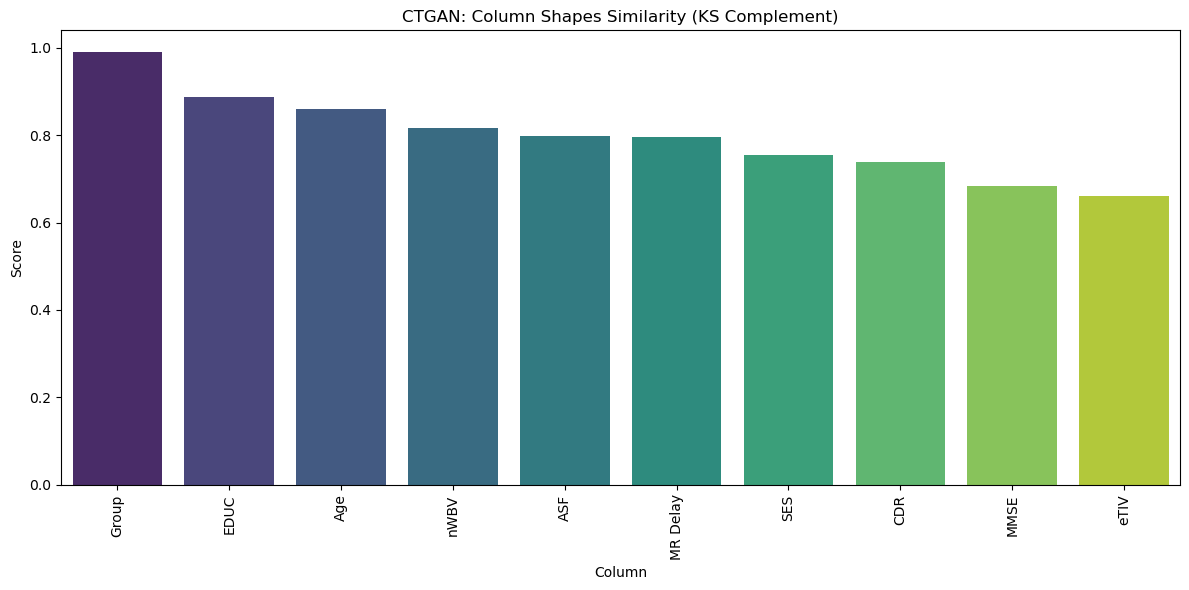

In [5]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt, seaborn as sns
quality_report_ctgan_ks = QualityReport()
quality_report_ctgan_ks.generate(
    real_data=real_df,
    synthetic_data=synthetic_data_ctgan,
    metadata=metadata.to_dict()  
)

details_ctgan = quality_report_ctgan_ks.get_details('Column Shapes')
print(details_ctgan)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Column', y='Score',
    data=details_ctgan.sort_values('Score', ascending=False),
    palette='viridis'
)
plt.title('CTGAN: Column Shapes Similarity (KS Complement)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 1.2. Jensen-Shannon Divergence

    Feature  JS_Divergence
0     Group       0.000064
2       Age       0.034755
8      nWBV       0.057726
1  MR Delay       0.070674
9       ASF       0.087795
7      eTIV       0.121552
3      EDUC       0.154543
6       CDR       0.233516
5      MMSE       0.295316
4       SES       0.329851


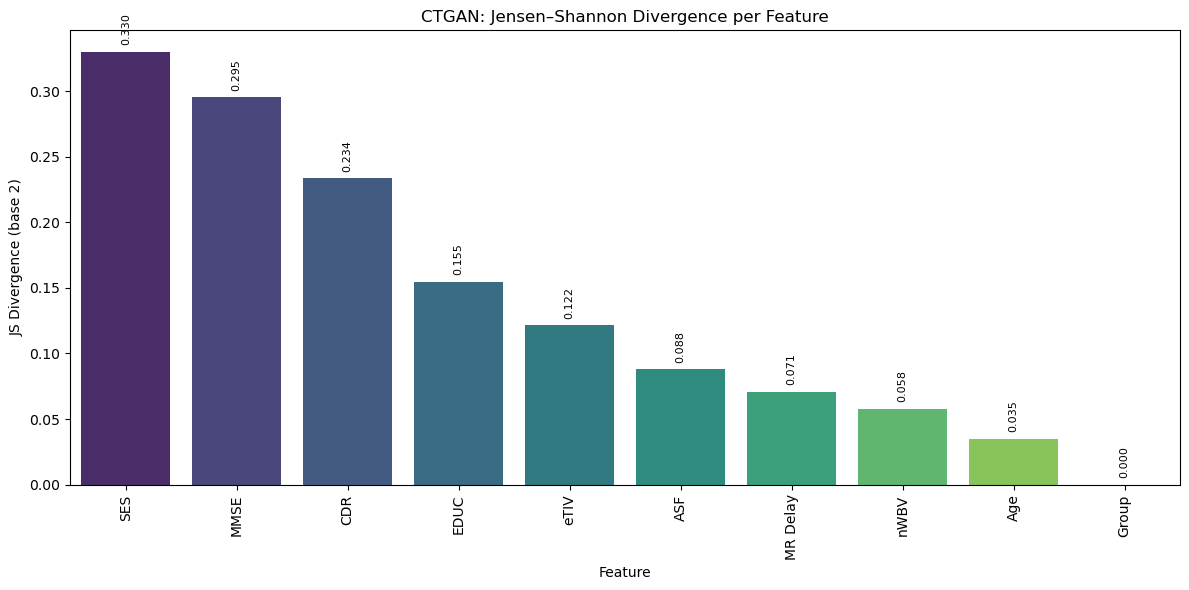

In [6]:
import numpy as np
results_ctgan_js = compute_js_divergence(real_df, synthetic_data_ctgan, bins="fd", normalize=True)
print(results_ctgan_js)

results_ctgan_js_sorted = results_ctgan_js.sort_values("JS_Divergence", ascending=False)
plt.figure(figsize=(12,6))
bars = sns.barplot(x="Feature", y="JS_Divergence", data=results_ctgan_js_sorted, palette="viridis")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha="center", va="bottom", fontsize=8, rotation=90)

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("CTGAN: Jensen–Shannon Divergence per Feature")
plt.tight_layout()
plt.show()

## 1.3 Wasserstein Distance

In [7]:
from scipy.stats import wasserstein_distance
scaler_ctgan = MinMaxScaler()
real_scaled_ctgan = pd.DataFrame(scaler_ctgan.fit_transform(real_df), columns=real_df.columns)
synthetic_scaled_ctgan = pd.DataFrame(scaler_ctgan.transform(synthetic_data_ctgan), columns=synthetic_data_ctgan.columns)

print("CTGAN - Wasserstein Distance:")
for col in real_df.columns:
    dist = wasserstein_distance(real_scaled_ctgan[col], synthetic_scaled_ctgan[col])
    print(f"{col}: {dist:.4f}")

CTGAN - Wasserstein Distance:
Group: 0.0094
MR Delay: 0.0607
Age: 0.0619
EDUC: 0.0418
SES: 0.0914
MMSE: 0.0335
CDR: 0.0637
eTIV: 0.1675
nWBV: 0.0787
ASF: 0.0962


## 1.4. Gower Distance  

In [8]:
import gower
X_real_ctgan = real_df.drop(['Group'], axis=1)
X_synth_ctgan = synthetic_data_ctgan.drop(['Group'], axis=1) 

gower_real_ctgan = 1 - gower.gower_matrix(X_real_ctgan)
gower_synth_ctgan = 1 - gower.gower_matrix(X_synth_ctgan)
gower_combined_ctgan = 1 - gower.gower_matrix(pd.concat([X_real_ctgan, X_synth_ctgan], axis=0))

real_upper_ctgan = gower_real_ctgan[np.triu_indices_from(gower_real_ctgan, k=1)]
synth_upper_ctgan = gower_synth_ctgan[np.triu_indices_from(gower_synth_ctgan, k=1)]

max_intra_real_ctgan = np.max(real_upper_ctgan)
avg_intra_real_ctgan = np.mean(real_upper_ctgan)
max_intra_synth_ctgan = np.max(synth_upper_ctgan)
avg_intra_synth_ctgan = np.mean(synth_upper_ctgan)

cross_flat_ctgan = gower_combined_ctgan.flatten()
max_cross_ctgan = np.max(cross_flat_ctgan)
avg_cross_ctgan = np.mean(cross_flat_ctgan)

print("CTGAN - Gower Distance:")
print("Intra-set Similarity (Real):")
print(f"Max = {max_intra_real_ctgan:.4f}, Avg = {avg_intra_real_ctgan:.4f}\n")
print("Intra-set Similarity (Synthetic):")
print(f"Max = {max_intra_synth_ctgan:.4f}, Avg = {avg_intra_synth_ctgan:.4f}\n")
print("Cross-set Similarity (Real vs Synthetic):")
print(f"Max = {max_cross_ctgan:.4f}, Avg = {avg_cross_ctgan:.4f}")

CTGAN - Gower Distance:
Intra-set Similarity (Real):
Max = 0.9885, Avg = 0.7824

Intra-set Similarity (Synthetic):
Max = 0.9857, Avg = 0.7661

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.7664


## 1.5 t-SNE Visualization

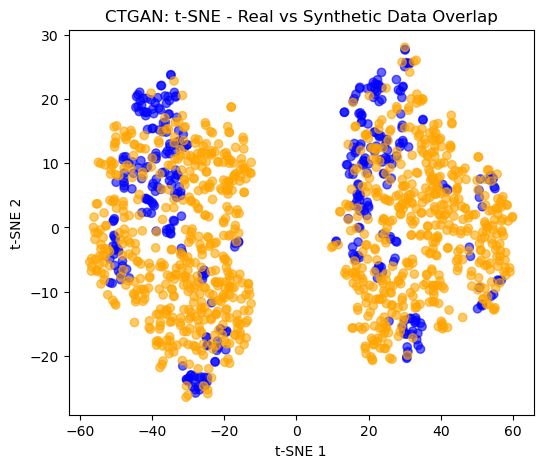

In [9]:
from sklearn.manifold import TSNE
tsne_ctgan = TSNE(n_components=2, random_state=42)
combined_ctgan = np.vstack([real_scaled_ctgan.values, synthetic_scaled_ctgan.values])
tsne_result_ctgan = tsne_ctgan.fit_transform(combined_ctgan)
labels_ctgan = ['Real'] * len(real_scaled_ctgan) + ['Synthetic'] * len(synthetic_scaled_ctgan)

plt.figure(figsize=(6,5))
plt.scatter(tsne_result_ctgan[:, 0], tsne_result_ctgan[:, 1],
            c=['blue' if l == 'Real' else 'orange' for l in labels_ctgan],
            alpha=0.6)
plt.title("CTGAN: t-SNE - Real vs Synthetic Data Overlap")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)

In [10]:
from sklearn.preprocessing import StandardScaler


scaler_mmd_ctgan = StandardScaler()
real_scaled_mmd_ctgan = scaler_mmd_ctgan.fit_transform(real_df.drop(columns=['Group']))
synthetic_scaled_mmd_ctgan = scaler_mmd_ctgan.transform(synthetic_data_ctgan.drop(columns=['Group']))

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile)**2, axis=1) / (2 * dim * sigma**2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

mmd_score_ctgan = compute_mmd(real_scaled_mmd_ctgan, synthetic_scaled_mmd_ctgan)
print(f"CTGAN - MMD score: {mmd_score_ctgan:.4f}")

CTGAN - MMD score: 0.0675


## 1.7 Privacy Check

In [11]:
from sklearn.neighbors import NearestNeighbors

nn_ctgan = NearestNeighbors(n_neighbors=1).fit(real_scaled_mmd_ctgan)
distances_ctgan, _ = nn_ctgan.kneighbors(synthetic_scaled_mmd_ctgan)
avg_nn_dist_ctgan = np.mean(distances_ctgan)

print("CTGAN - Privacy Check:")
print(f"Average Nearest Neighbor Distance (Synthetic → Real): {avg_nn_dist_ctgan:.4f}")

CTGAN - Privacy Check:
Average Nearest Neighbor Distance (Synthetic → Real): 2.2185


## 1.8 Bivariate Analysis

In [14]:
real_df_ctgan = real_df
synth_df_ctgan = synthetic_data_ctgan
synth_df_ctgan = synth_df_ctgan[real_df_ctgan.columns]

corr_results_ctgan, target_results_ctgan = bivariate_quality_ad(
    real_df=real_df_ctgan, 
    synth_df=synth_df_ctgan
)

print("CTGAN - Largest differences in pairwise correlations:")
print(corr_results_ctgan.head(10))
print('================================')
print("CTGAN - Features that differ most by diagnosis class:")
print(target_results_ctgan.head(10))

CTGAN - Largest differences in pairwise correlations:
       var_a var_b  delta_corr
34      eTIV   ASF    0.942047
15      EDUC   SES    0.721646
26      MMSE   CDR    0.707668
13       Age  nWBV    0.416409
23       SES  eTIV    0.347589
28      MMSE  nWBV    0.296431
31       CDR  nWBV    0.276591
20      EDUC   ASF    0.260879
0   MR Delay   Age    0.252206
33      eTIV  nWBV    0.251354
CTGAN - Features that differ most by diagnosis class:
    feature  delta_wasserstein
5       CDR           0.256484
4      MMSE           0.119241
7      nWBV           0.108928
2      EDUC           0.048981
0  MR Delay           0.039146
6      eTIV           0.029839
1       Age           0.023842
3       SES           0.014938
8       ASF           0.002836


## 1.11 Multivariate Analysis

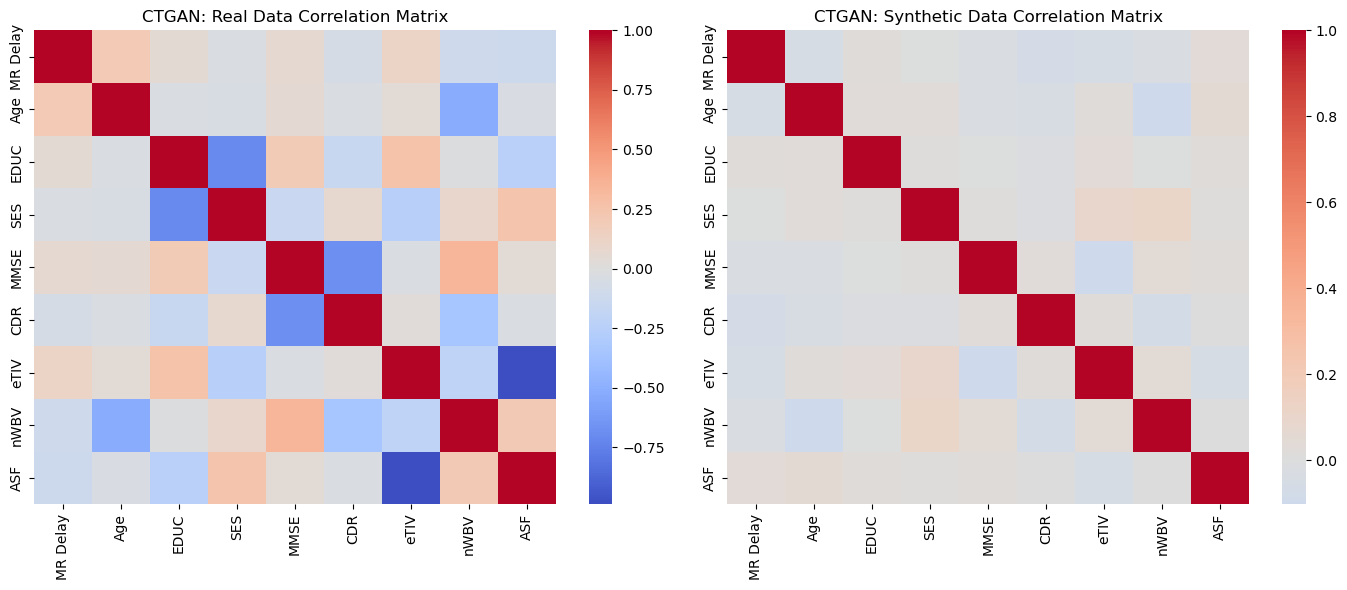

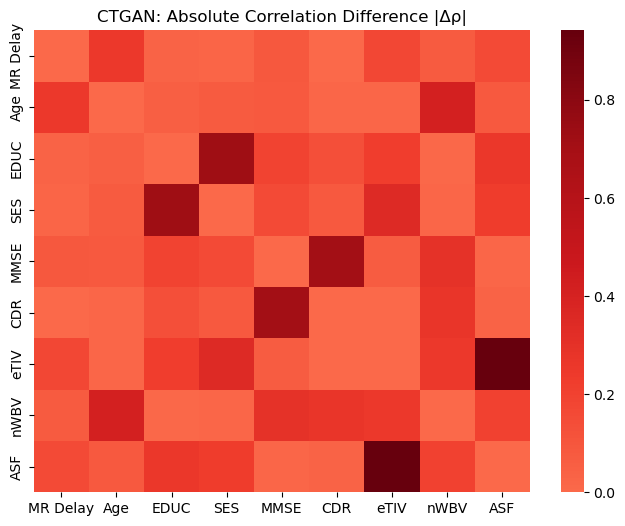

In [15]:
# Correlation heatmaps for CopulaGAN

num_cols = [c for c in real_df_ctgan.columns if c != "Group"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(real_df_ctgan[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("CTGAN: Real Data Correlation Matrix")

sns.heatmap(synth_df_ctgan[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("CTGAN: Synthetic Data Correlation Matrix")

plt.tight_layout()
plt.show()

diff_corr_copulagan = abs(real_df_ctgan[num_cols].corr() - synth_df_ctgan[num_cols].corr())
plt.figure(figsize=(8,6))
sns.heatmap(diff_corr_copulagan, cmap="Reds", center=0)
plt.title("CTGAN: Absolute Correlation Difference |Δρ|")
plt.show()

CTGAN - Global MMD (RBF): 0.04635964707306961


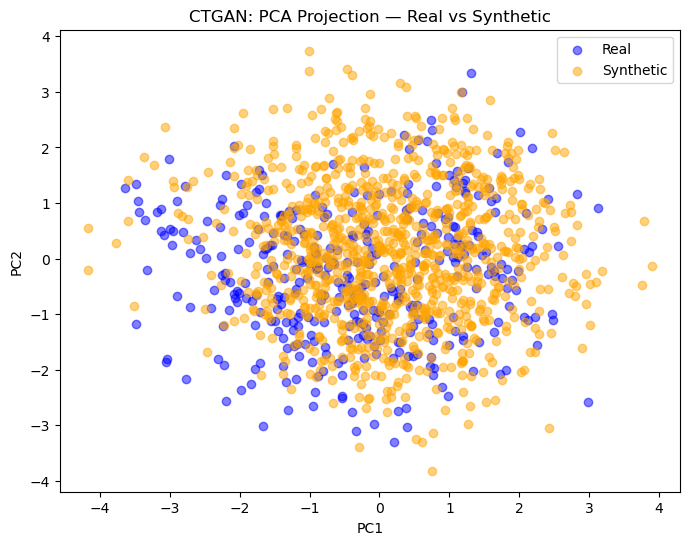

CTGAN - Two-Sample Classifier Accuracy: 0.9757281553398058


In [16]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:,None,:]-Z[None,:,:])**2).sum(-1))
        med = np.median(dists[dists>0])
        gamma = 1.0 / (2*(med**2))
    Kxx = rbf_kernel(X, X, gamma)
    Kyy = rbf_kernel(Y, Y, gamma)
    Kxy = rbf_kernel(X, Y, gamma)
    n, m = len(X), len(Y)
    return (Kxx.sum() - np.trace(Kxx))/(n*(n-1)) + (Kyy.sum() - np.trace(Kyy))/(m*(m-1)) - 2*Kxy.mean()

X_real_mv_ctgan = scaler_mmd_ctgan.fit_transform(real_df.drop(columns=['Group']))
X_synth_mv_ctgan = scaler_mmd_ctgan.transform(synthetic_data_ctgan.drop(columns=['Group']))

mmd_value_ctgan = mmd_rbf(X_real_mv_ctgan, X_synth_mv_ctgan)
print(f"CTGAN - Global MMD (RBF): {mmd_value_ctgan}")

# PCA visualization
pca_ctgan = PCA(n_components=2)
X_all_ctgan = np.vstack([X_real_mv_ctgan, X_synth_mv_ctgan])
labels_mv_ctgan = np.array(['Real'] * len(X_real_mv_ctgan) + ['Synthetic'] * len(X_synth_mv_ctgan))
X_pca_ctgan = pca_ctgan.fit_transform(X_all_ctgan)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_ctgan[labels_mv_ctgan=='Real',0], X_pca_ctgan[labels_mv_ctgan=='Real',1], 
            color='blue', alpha=0.5, label='Real')
plt.scatter(X_pca_ctgan[labels_mv_ctgan=='Synthetic',0], X_pca_ctgan[labels_mv_ctgan=='Synthetic',1], 
            color='orange', alpha=0.5, label='Synthetic')
plt.title("CTGAN: PCA Projection — Real vs Synthetic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# Classifier Two-Sample Test
y_real_mv_ctgan = np.ones(len(X_real_mv_ctgan))
y_synth_mv_ctgan = np.zeros(len(X_synth_mv_ctgan))
X_mv_ctgan = np.vstack([X_real_mv_ctgan, X_synth_mv_ctgan])
y_mv_ctgan = np.hstack([y_real_mv_ctgan, y_synth_mv_ctgan])

X_train_mv_ctgan, X_test_mv_ctgan, y_train_mv_ctgan, y_test_mv_ctgan = train_test_split(
    X_mv_ctgan, y_mv_ctgan, test_size=0.3, stratify=y_mv_ctgan, random_state=42
)
clf_mv_ctgan = RandomForestClassifier(n_estimators=200, random_state=42)
clf_mv_ctgan.fit(X_train_mv_ctgan, y_train_mv_ctgan)
y_pred_mv_ctgan = clf_mv_ctgan.predict(X_test_mv_ctgan)
acc_mv_ctgan = accuracy_score(y_test_mv_ctgan, y_pred_mv_ctgan)
print(f"CTGAN - Two-Sample Classifier Accuracy: {acc_mv_ctgan}")

# 2 CopulaGAN Model
CopulaGAN is a GAN-based synthetic data generator for tabular data that uses copulas to better model dependencies between features.

GAN component: Learns the overall data distribution and generates synthetic samples.

Copula component: Models dependence structure between columns, especially useful for non-Gaussian or skewed distributions.

In [17]:
from sdv.single_table import CopulaGANSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Train CopulaGAN model
copulagan = CopulaGANSynthesizer(metadata)
copulagan.fit(real_df)
synthetic_data_copulagan = copulagan.sample(1000)

# Diagnostic and quality check
diagnostic_report_copulagan = run_diagnostic(real_df, synthetic_data_copulagan, metadata) 
quality_report_copulagan = evaluate_quality(real_df, synthetic_data_copulagan, metadata)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 10/10 [00:00<00:00, 562.98it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 566.48it/s]|
Column Shapes Score: 72.14%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 291.10it/s]|
Column Pair Trends Score: 84.58%

Overall Score (Average): 78.36%



## 2.1 Kolmogorov-Smirnov (KS) Test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 425.64it/s]|
Column Shapes Score: 72.14%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 334.58it/s]|
Column Pair Trends Score: 84.58%

Overall Score (Average): 78.36%

     Column        Metric     Score
0     Group  TVComplement  0.985617
1  MR Delay  KSComplement  0.747231
2       Age  KSComplement  0.706434
3      EDUC  KSComplement  0.783188
4       SES  KSComplement  0.487936
5      MMSE  KSComplement  0.709370
6       CDR  KSComplement  0.793279
7      eTIV  KSComplement  0.641206
8      nWBV  KSComplement  0.444324
9       ASF  KSComplement  0.915005


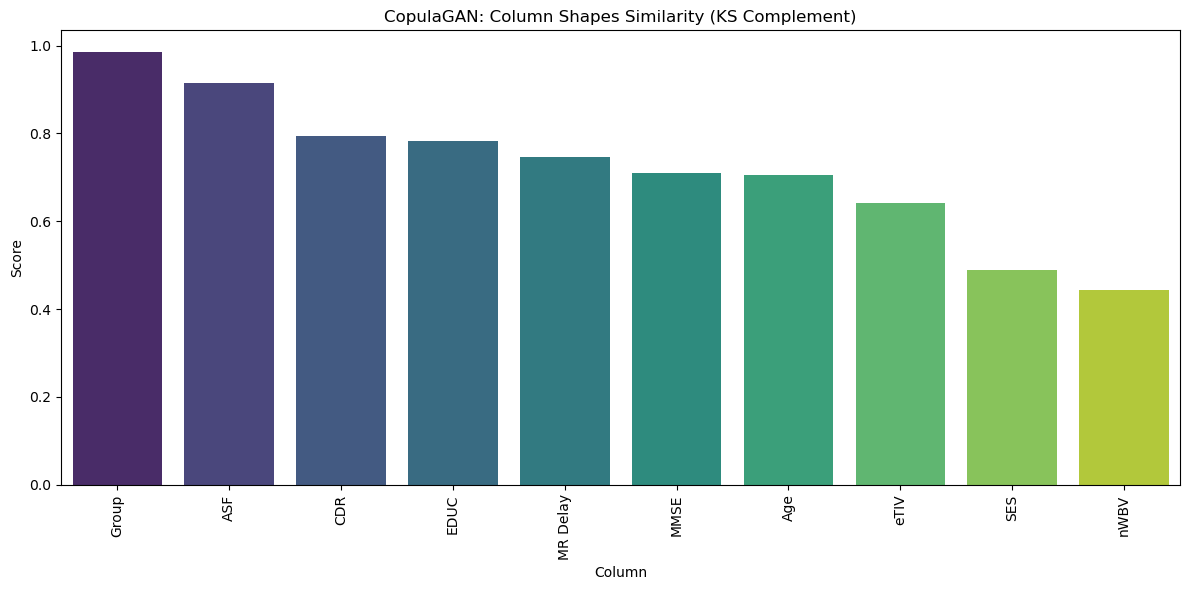

In [18]:
from sdv.evaluation.single_table import QualityReport
import seaborn as sns
import matplotlib.pyplot as plt

# Generate quality report for CopulaGAN
quality_report_copulagan_ks = QualityReport()
quality_report_copulagan_ks.generate(
    real_data=real_df,
    synthetic_data=synthetic_data_copulagan,
    metadata=metadata.to_dict()  
)

details_copulagan = quality_report_copulagan_ks.get_details('Column Shapes')
print(details_copulagan)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(
    x='Column', y='Score',
    data=details_copulagan.sort_values('Score', ascending=False),
    palette='viridis'
)
plt.title('CopulaGAN: Column Shapes Similarity (KS Complement)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.2 Jensen-Shannon Divergence

    Feature  JS_Divergence
0     Group       0.000149
9       ASF       0.024203
1  MR Delay       0.076547
5      MMSE       0.078877
2       Age       0.098839
7      eTIV       0.136258
3      EDUC       0.158961
6       CDR       0.280218
8      nWBV       0.316464
4       SES       0.431857


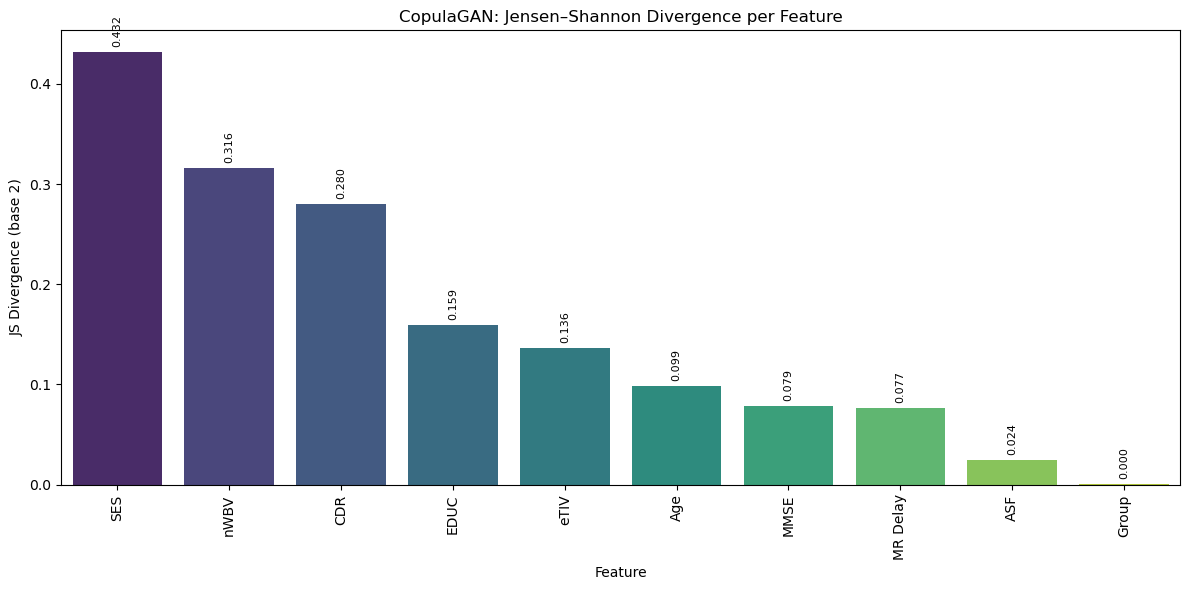

In [19]:
results_copulagan_js = compute_js_divergence(real_df, synthetic_data_copulagan, bins="fd", normalize=True)
print(results_copulagan_js)

# Visualization
results_copulagan_js_sorted = results_copulagan_js.sort_values("JS_Divergence", ascending=False)
plt.figure(figsize=(12,6))
bars = sns.barplot(x="Feature", y="JS_Divergence", data=results_copulagan_js_sorted, palette="viridis")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.005,
        f"{yval:.3f}",
        ha="center", va="bottom", fontsize=8, rotation=90
    )

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("CopulaGAN: Jensen–Shannon Divergence per Feature")
plt.tight_layout()
plt.show()

### 2.3 Wasserstein Distance

In [20]:
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import wasserstein_distance

scaler_copulagan = MinMaxScaler()
real_scaled_copulagan = pd.DataFrame(scaler_copulagan.fit_transform(real_df), columns=real_df.columns)
synthetic_scaled_copulagan = pd.DataFrame(scaler_copulagan.transform(synthetic_data_copulagan), columns=synthetic_data_copulagan.columns)

# Compute normalized Wasserstein distance
print("CopulaGAN - Wasserstein Distance:")
for col in real_df.columns:
    dist = wasserstein_distance(real_scaled_copulagan[col], synthetic_scaled_copulagan[col])
    print(f"{col}: {dist:.4f}")

CopulaGAN - Wasserstein Distance:
Group: 0.0144
MR Delay: 0.0643
Age: 0.1272
EDUC: 0.0685
SES: 0.1964
MMSE: 0.0716
CDR: 0.0847
eTIV: 0.1754
nWBV: 0.3055
ASF: 0.0301


2.4 Gower Distance

In [21]:
import gower

X_real_copulagan = real_df.drop(columns=['Group'])
X_synth_copulagan = synthetic_data_copulagan.drop(columns=['Group'])

gower_real_copulagan = 1 - gower.gower_matrix(X_real_copulagan)
gower_synth_copulagan = 1 - gower.gower_matrix(X_synth_copulagan)
gower_cross_copulagan = 1 - gower.gower_matrix(X_real_copulagan, X_synth_copulagan)

real_upper_copulagan = gower_real_copulagan[np.triu_indices_from(gower_real_copulagan, k=1)]
synth_upper_copulagan = gower_synth_copulagan[np.triu_indices_from(gower_synth_copulagan, k=1)]

max_intra_real_copulagan = np.max(real_upper_copulagan)
avg_intra_real_copulagan = np.mean(real_upper_copulagan)
max_intra_synth_copulagan = np.max(synth_upper_copulagan)
avg_intra_synth_copulagan = np.mean(synth_upper_copulagan)

cross_flat_copulagan = gower_cross_copulagan.flatten()
max_cross_copulagan = np.max(cross_flat_copulagan)
avg_cross_copulagan = np.mean(cross_flat_copulagan)

print("CopulaGAN - Gower Distance:")
print("Intra-set Similarity (Real):")
print(f"Max = {max_intra_real_copulagan:.4f}, Avg = {avg_intra_real_copulagan:.4f}\n")
print("Intra-set Similarity (Synthetic):")
print(f"Max = {max_intra_synth_copulagan:.4f}, Avg = {avg_intra_synth_copulagan:.4f}\n")
print("Cross-set Similarity (Real vs Synthetic):")
print(f"Max = {max_cross_copulagan:.4f}, Avg = {avg_cross_copulagan:.4f}")

CopulaGAN - Gower Distance:
Intra-set Similarity (Real):
Max = 0.9885, Avg = 0.7824

Intra-set Similarity (Synthetic):
Max = 0.9807, Avg = 0.7281

Cross-set Similarity (Real vs Synthetic):
Max = 0.9744, Avg = 0.7317


2.5 t-SNE Visualization

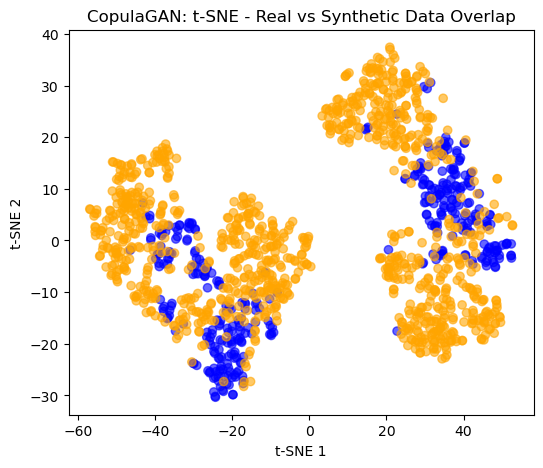

In [22]:
from sklearn.manifold import TSNE

tsne_copulagan = TSNE(n_components=2, random_state=42)
combined_copulagan = np.vstack([real_scaled_copulagan.values, synthetic_scaled_copulagan.values])
tsne_result_copulagan = tsne_copulagan.fit_transform(combined_copulagan)
labels_copulagan = ['Real'] * len(real_scaled_copulagan) + ['Synthetic'] * len(synthetic_scaled_copulagan)

plt.figure(figsize=(6,5))
plt.scatter(tsne_result_copulagan[:, 0], tsne_result_copulagan[:, 1],
            c=['blue' if l == 'Real' else 'orange' for l in labels_copulagan],
            alpha=0.6)
plt.title("CopulaGAN: t-SNE - Real vs Synthetic Data Overlap")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

2.6 MMD (Maximum Mean Discrepancy)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler_mmd_copulagan = StandardScaler()
real_scaled_mmd_copulagan = scaler_mmd_copulagan.fit_transform(real_df.drop(columns=['Group']))
synthetic_scaled_mmd_copulagan = scaler_mmd_copulagan.transform(synthetic_data_copulagan.drop(columns=['Group']))

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile)**2, axis=1) / (2 * dim * sigma**2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

mmd_score_copulagan = compute_mmd(real_scaled_mmd_copulagan, synthetic_scaled_mmd_copulagan)
print(f"CopulaGAN - MMD score: {mmd_score_copulagan:.4f}")

CopulaGAN - MMD score: 0.1573


2.7 Cosine Similarity

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

cross_sim_copulagan = cosine_similarity(real_scaled_mmd_copulagan, synthetic_scaled_mmd_copulagan)
avg_sim_copulagan = np.mean(cross_sim_copulagan)
max_sim_copulagan = np.max(cross_sim_copulagan)

print("CopulaGAN - Sample-Level Similarity:")
print(f"Average cosine similarity: {avg_sim_copulagan:.4f}")
print(f"Maximum cosine similarity: {max_sim_copulagan:.4f}")

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0016
Maximum cosine similarity: 0.9884


2.8 Privacy Check

In [25]:
from sklearn.neighbors import NearestNeighbors

nn_copulagan = NearestNeighbors(n_neighbors=1).fit(real_scaled_mmd_copulagan)
distances_copulagan, _ = nn_copulagan.kneighbors(synthetic_scaled_mmd_copulagan)
avg_nn_dist_copulagan = np.mean(distances_copulagan)

print("CopulaGAN - Privacy Check:")
print(f"Average Nearest Neighbor Distance (Synthetic → Real): {avg_nn_dist_copulagan:.4f}")

CopulaGAN - Privacy Check:
Average Nearest Neighbor Distance (Synthetic → Real): 2.6551


2.9 Bivariate Analysis

In [26]:
real_df_copulagan = real_df
synth_df_copulagan = synthetic_data_copulagan
synth_df_copulagan = synth_df_copulagan[real_df_copulagan.columns]

corr_results_copulagan, target_results_copulagan = bivariate_quality_ad(
    real_df=real_df_copulagan, 
    synth_df=synth_df_copulagan
)

print("CopulaGAN - Largest differences in pairwise correlations:")
print(corr_results_copulagan.head(10))
print('================================')
print("CopulaGAN - Features that differ most by diagnosis class:")
print(target_results_copulagan.head(10))

CopulaGAN - Largest differences in pairwise correlations:
   var_a var_b  delta_corr
34  eTIV   ASF    0.976318
26  MMSE   CDR    0.715775
15  EDUC   SES    0.681358
13   Age  nWBV    0.606863
31   CDR  nWBV    0.342036
33  eTIV  nWBV    0.306659
25   SES   ASF    0.295868
23   SES  eTIV    0.285441
28  MMSE  nWBV    0.277559
18  EDUC  eTIV    0.235385
CopulaGAN - Features that differ most by diagnosis class:
    feature  delta_wasserstein
5       CDR           0.184803
6      eTIV           0.141115
4      MMSE           0.139024
2      EDUC           0.058636
7      nWBV           0.056269
0  MR Delay           0.051069
3       SES           0.043995
8       ASF           0.004118
1       Age           0.000251


2.11 Multivariate Analysis

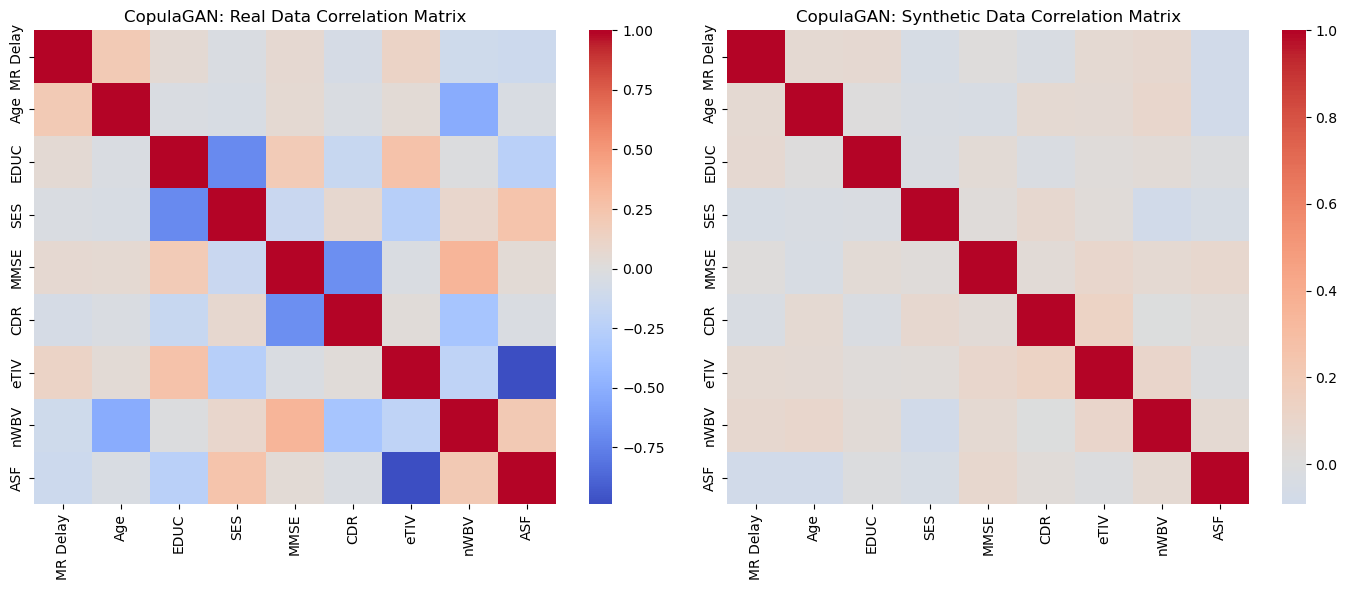

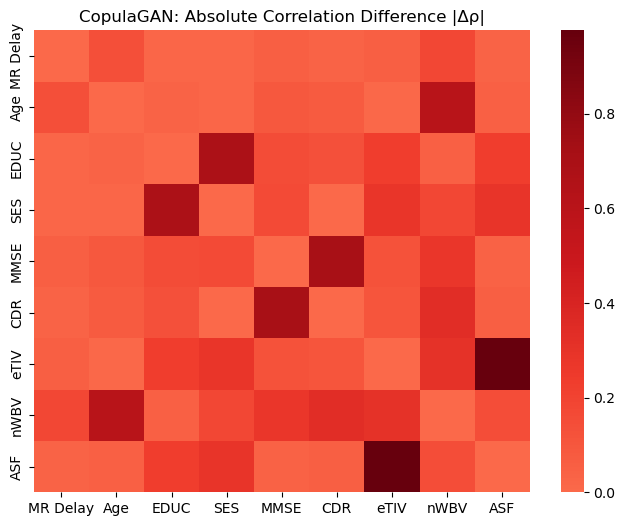

In [27]:
# Correlation heatmaps for CopulaGAN
num_cols = [c for c in real_df_copulagan.columns if c != "Group"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(real_df_copulagan[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("CopulaGAN: Real Data Correlation Matrix")

sns.heatmap(synth_df_copulagan[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("CopulaGAN: Synthetic Data Correlation Matrix")

plt.tight_layout()
plt.show()

diff_corr_copulagan = abs(real_df_copulagan[num_cols].corr() - synth_df_copulagan[num_cols].corr())
plt.figure(figsize=(8,6))
sns.heatmap(diff_corr_copulagan, cmap="Reds", center=0)
plt.title("CopulaGAN: Absolute Correlation Difference |Δρ|")
plt.show()

CopulaGAN - Global MMD (RBF): 0.11600038634814891


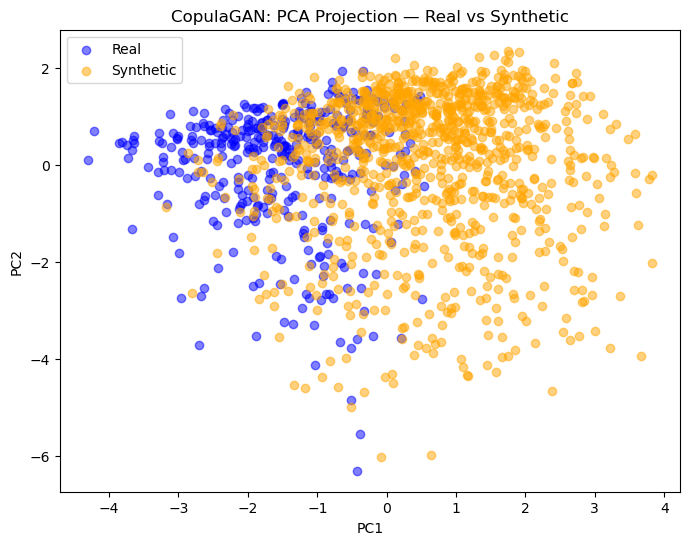

CopulaGAN - Two-Sample Classifier Accuracy: 0.9587378640776699


In [29]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:,None,:]-Z[None,:,:])**2).sum(-1))
        med = np.median(dists[dists>0])
        gamma = 1.0 / (2*(med**2))
    Kxx = rbf_kernel(X, X, gamma)
    Kyy = rbf_kernel(Y, Y, gamma)
    Kxy = rbf_kernel(X, Y, gamma)
    n, m = len(X), len(Y)
    return (Kxx.sum() - np.trace(Kxx))/(n*(n-1)) + (Kyy.sum() - np.trace(Kyy))/(m*(m-1)) - 2*Kxy.mean()

X_real_mv_copulagan = scaler_mmd_copulagan.fit_transform(real_df.drop(columns=['Group']))
X_synth_mv_copulagan = scaler_mmd_copulagan.transform(synthetic_data_copulagan.drop(columns=['Group']))

mmd_value_copulagan = mmd_rbf(X_real_mv_copulagan, X_synth_mv_copulagan)
print(f"CopulaGAN - Global MMD (RBF): {mmd_value_copulagan}")

# PCA visualization
pca_copulagan = PCA(n_components=2)
X_all_copulagan = np.vstack([X_real_mv_copulagan, X_synth_mv_copulagan])
labels_mv_copulagan = np.array(['Real'] * len(X_real_mv_copulagan) + ['Synthetic'] * len(X_synth_mv_copulagan))
X_pca_copulagan = pca_copulagan.fit_transform(X_all_copulagan)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_copulagan[labels_mv_copulagan=='Real',0], X_pca_copulagan[labels_mv_copulagan=='Real',1], 
            color='blue', alpha=0.5, label='Real')
plt.scatter(X_pca_copulagan[labels_mv_copulagan=='Synthetic',0], X_pca_copulagan[labels_mv_copulagan=='Synthetic',1], 
            color='orange', alpha=0.5, label='Synthetic')
plt.title("CopulaGAN: PCA Projection — Real vs Synthetic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# Classifier Two-Sample Test
y_real_mv_copulagan = np.ones(len(X_real_mv_copulagan))
y_synth_mv_copulagan = np.zeros(len(X_synth_mv_copulagan))
X_mv_copulagan = np.vstack([X_real_mv_copulagan, X_synth_mv_copulagan])
y_mv_copulagan = np.hstack([y_real_mv_copulagan, y_synth_mv_copulagan])

X_train_mv_copulagan, X_test_mv_copulagan, y_train_mv_copulagan, y_test_mv_copulagan = train_test_split(
    X_mv_copulagan, y_mv_copulagan, test_size=0.3, stratify=y_mv_copulagan, random_state=42
)
clf_mv_copulagan = RandomForestClassifier(n_estimators=200, random_state=42)
clf_mv_copulagan.fit(X_train_mv_copulagan, y_train_mv_copulagan)
y_pred_mv_copulagan = clf_mv_copulagan.predict(X_test_mv_copulagan)
acc_mv_copulagan = accuracy_score(y_test_mv_copulagan, y_pred_mv_copulagan)
print(f"CopulaGAN - Two-Sample Classifier Accuracy: {acc_mv_copulagan}")

# 3. Gaussian Copula

In [30]:
from sdv.single_table import GaussianCopulaSynthesizer

# Train Gaussian Copula model
gaussiancopula = GaussianCopulaSynthesizer(metadata)
gaussiancopula.fit(real_df)
synthetic_data_gaussiancopula = gaussiancopula.sample(num_rows=1000)

# Diagnostic and quality check
diagnostic_report_gaussiancopula = run_diagnostic(real_df, synthetic_data_gaussiancopula, metadata)
quality_report_gaussiancopula = evaluate_quality(real_df, synthetic_data_gaussiancopula, metadata)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 10/10 [00:00<00:00, 2238.39it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 495.84it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 580.37it/s]|
Column Shapes Score: 79.69%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 479.49it/s]|
Column Pair Trends Score: 92.56%

Overall Score (Average): 86.12%



3.1 Kolmogorov-Smirnov (KS) Test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 428.30it/s]|
Column Shapes Score: 79.69%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 339.49it/s]|
Column Pair Trends Score: 92.56%

Overall Score (Average): 86.12%

     Column        Metric     Score
0     Group  TVComplement  0.976617
1  MR Delay  KSComplement  0.464273
2       Age  KSComplement  0.982113
3      EDUC  KSComplement  0.899236
4       SES  KSComplement  0.487936
5      MMSE  KSComplement  0.685630
6       CDR  KSComplement  0.653279
7      eTIV  KSComplement  0.942118
8      nWBV  KSComplement  0.934155
9       ASF  KSComplement  0.943437


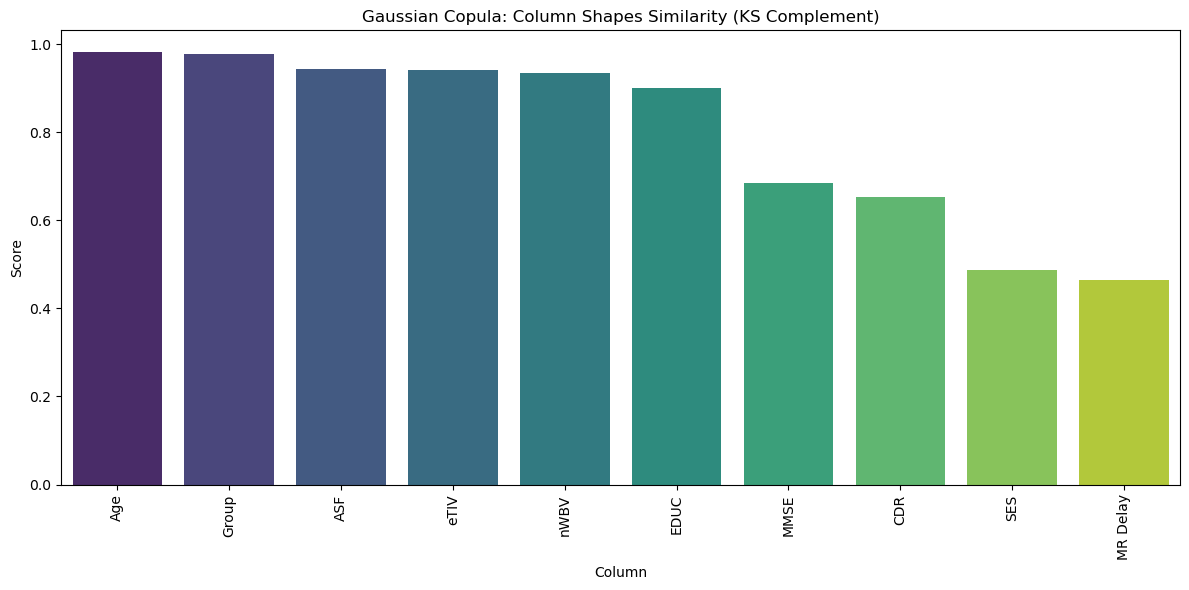

In [31]:
quality_report_gaussiancopula_ks = QualityReport()
quality_report_gaussiancopula_ks.generate(
    real_data=real_df,
    synthetic_data=synthetic_data_gaussiancopula,
    metadata=metadata.to_dict()  
)

details_gaussiancopula = quality_report_gaussiancopula_ks.get_details('Column Shapes')
print(details_gaussiancopula)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Column', y='Score',
    data=details_gaussiancopula.sort_values('Score', ascending=False),
    palette='viridis'
)
plt.title('Gaussian Copula: Column Shapes Similarity (KS Complement)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

3.2 Jensen-Shannon Divergence

    Feature  JS_Divergence
0     Group       0.000394
2       Age       0.002943
8      nWBV       0.006916
9       ASF       0.022145
7      eTIV       0.031066
3      EDUC       0.169810
6       CDR       0.306750
1  MR Delay       0.357102
5      MMSE       0.373539
4       SES       0.583030


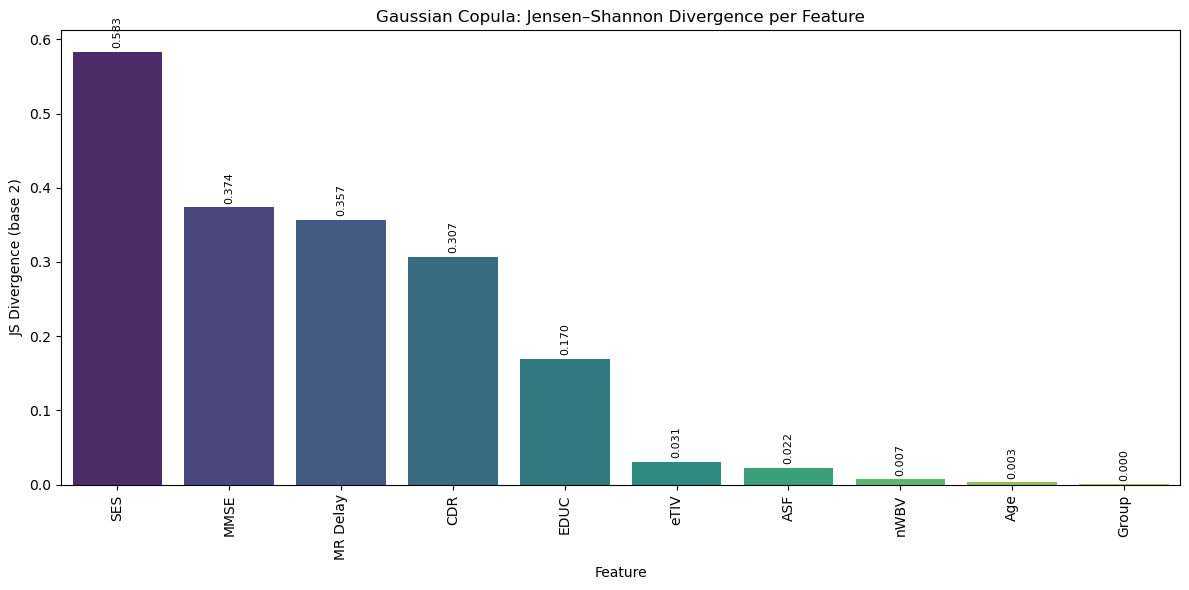

In [32]:
results_gaussiancopula_js = compute_js_divergence(real_df, synthetic_data_gaussiancopula, bins="fd", normalize=True)
print(results_gaussiancopula_js)

results_gaussiancopula_js_sorted = results_gaussiancopula_js.sort_values("JS_Divergence", ascending=False)
plt.figure(figsize=(12,6))
bars = sns.barplot(x="Feature", y="JS_Divergence", data=results_gaussiancopula_js_sorted, palette="viridis")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha="center", va="bottom", fontsize=8, rotation=90)

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("Gaussian Copula: Jensen–Shannon Divergence per Feature")
plt.tight_layout()
plt.show()

3.3 Wasserstein Distance

In [33]:
scaler_gaussiancopula = MinMaxScaler()
real_scaled_gaussiancopula = pd.DataFrame(scaler_gaussiancopula.fit_transform(real_df), columns=real_df.columns)
synthetic_scaled_gaussiancopula = pd.DataFrame(scaler_gaussiancopula.transform(synthetic_data_gaussiancopula), columns=synthetic_data_gaussiancopula.columns)

print("Gaussian Copula - Wasserstein Distance:")
for col in real_df.columns:
    dist = wasserstein_distance(real_scaled_gaussiancopula[col], synthetic_scaled_gaussiancopula[col])
    print(f"{col}: {dist:.4f}")

Gaussian Copula - Wasserstein Distance:
Group: 0.0234
MR Delay: 0.1994
Age: 0.0057
EDUC: 0.0307
SES: 0.1204
MMSE: 0.0622
CDR: 0.0891
eTIV: 0.0170
nWBV: 0.0145
ASF: 0.0166


3.4 Gower Distance

In [34]:
X_real_gaussiancopula = real_df.drop('Group', axis=1)
X_synth_gaussiancopula = synthetic_data_gaussiancopula.drop('Group', axis=1) 

gower_real_gaussiancopula = 1 - gower.gower_matrix(X_real_gaussiancopula)
gower_synth_gaussiancopula = 1 - gower.gower_matrix(X_synth_gaussiancopula)
gower_combined_gaussiancopula = 1 - gower.gower_matrix(pd.concat([X_real_gaussiancopula, X_synth_gaussiancopula], axis=0))

real_upper_gaussiancopula = gower_real_gaussiancopula[np.triu_indices_from(gower_real_gaussiancopula, k=1)]
synth_upper_gaussiancopula = gower_synth_gaussiancopula[np.triu_indices_from(gower_synth_gaussiancopula, k=1)]

max_intra_real_gaussiancopula = np.max(real_upper_gaussiancopula)
avg_intra_real_gaussiancopula = np.mean(real_upper_gaussiancopula)
max_intra_synth_gaussiancopula = np.max(synth_upper_gaussiancopula)
avg_intra_synth_gaussiancopula = np.mean(synth_upper_gaussiancopula)

cross_flat_gaussiancopula = gower_combined_gaussiancopula.flatten()
max_cross_gaussiancopula = np.max(cross_flat_gaussiancopula)
avg_cross_gaussiancopula = np.mean(cross_flat_gaussiancopula)

print("Gaussian Copula - Gower Distance:")
print("Intra-set Similarity (Real):")
print(f"Max = {max_intra_real_gaussiancopula:.4f}, Avg = {avg_intra_real_gaussiancopula:.4f}\n")
print("Intra-set Similarity (Synthetic):")
print(f"Max = {max_intra_synth_gaussiancopula:.4f}, Avg = {avg_intra_synth_gaussiancopula:.4f}\n")
print("Cross-set Similarity (Real vs Synthetic):")
print(f"Max = {max_cross_gaussiancopula:.4f}, Avg = {avg_cross_gaussiancopula:.4f}")

Gaussian Copula - Gower Distance:
Intra-set Similarity (Real):
Max = 0.9885, Avg = 0.7824

Intra-set Similarity (Synthetic):
Max = 0.9903, Avg = 0.8220

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.8172


3.5 t-SNE Visualization

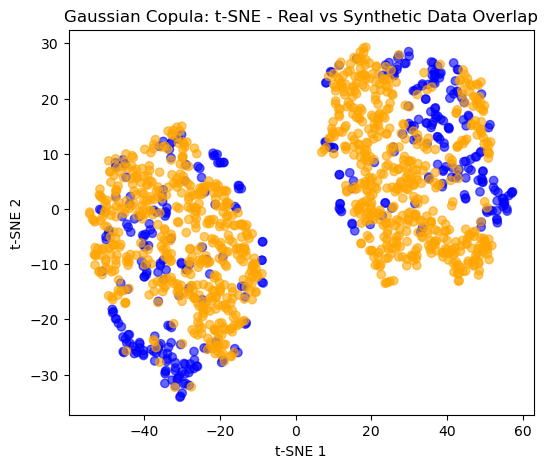

In [35]:
tsne_gaussiancopula = TSNE(n_components=2, random_state=42)
combined_gaussiancopula = np.vstack([real_scaled_gaussiancopula.values, synthetic_scaled_gaussiancopula.values])
tsne_result_gaussiancopula = tsne_gaussiancopula.fit_transform(combined_gaussiancopula)
labels_gaussiancopula = ['Real'] * len(real_scaled_gaussiancopula) + ['Synthetic'] * len(synthetic_scaled_gaussiancopula)

plt.figure(figsize=(6,5))
plt.scatter(tsne_result_gaussiancopula[:, 0], tsne_result_gaussiancopula[:, 1],
            c=['blue' if l == 'Real' else 'orange' for l in labels_gaussiancopula],
            alpha=0.6)
plt.title("Gaussian Copula: t-SNE - Real vs Synthetic Data Overlap")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

3.6 MMD (Maximum Mean Discrepancy)

In [36]:
scaler_mmd_gaussiancopula = StandardScaler()
real_scaled_mmd_gaussiancopula = scaler_mmd_gaussiancopula.fit_transform(real_df.drop(columns=['Group']))
synthetic_scaled_mmd_gaussiancopula = scaler_mmd_gaussiancopula.transform(synthetic_data_gaussiancopula.drop(columns=['Group']))

mmd_score_gaussiancopula = compute_mmd(real_scaled_mmd_gaussiancopula, synthetic_scaled_mmd_gaussiancopula)
print(f"Gaussian Copula - MMD score: {mmd_score_gaussiancopula:.4f}")

Gaussian Copula - MMD score: 0.0603


3.7 Cosine Similarity

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

cross_sim_gaussiancopula = cosine_similarity(real_scaled_mmd_gaussiancopula, synthetic_scaled_mmd_gaussiancopula)
avg_sim_gaussiancopula = np.mean(cross_sim_gaussiancopula)
max_sim_gaussiancopula = np.max(cross_sim_gaussiancopula)

print("Gaussian Copula - Sample-Level Similarity:")
print(f"Average cosine similarity: {avg_sim_gaussiancopula:.4f}")
print(f"Maximum cosine similarity: {max_sim_gaussiancopula:.4f}")

Gaussian Copula - Sample-Level Similarity:
Average cosine similarity: 0.0187
Maximum cosine similarity: 0.9938


3.8 Privacy Check

In [39]:
nn_gaussiancopula = NearestNeighbors(n_neighbors=1).fit(real_scaled_mmd_gaussiancopula)
distances_gaussiancopula, _ = nn_gaussiancopula.kneighbors(synthetic_scaled_mmd_gaussiancopula)
avg_nn_dist_gaussiancopula = np.mean(distances_gaussiancopula)

print("Gaussian Copula - Privacy Check:")
print(f"Average Nearest Neighbor Distance (Synthetic → Real): {avg_nn_dist_gaussiancopula:.4f}")

Gaussian Copula - Privacy Check:
Average Nearest Neighbor Distance (Synthetic → Real): 1.2092


3.10 Bivariate Analysis

In [40]:
real_df_gaussiancopula = real_df
synth_df_gaussiancopula = synthetic_data_gaussiancopula
synth_df_gaussiancopula = synth_df_gaussiancopula[real_df_gaussiancopula.columns]

corr_results_gaussiancopula, target_results_gaussiancopula = bivariate_quality_ad(
    real_df=real_df_gaussiancopula, 
    synth_df=synth_df_gaussiancopula
)

print("Gaussian Copula - Largest differences in pairwise correlations:")
print(corr_results_gaussiancopula.head(10))
print('================================')
print("Gaussian Copula - Features that differ most by diagnosis class:")
print(target_results_gaussiancopula.head(10))

Gaussian Copula - Largest differences in pairwise correlations:
       var_a var_b  delta_corr
26      MMSE   CDR    0.185067
28      MMSE  nWBV    0.130352
7   MR Delay   ASF    0.100913
5   MR Delay  eTIV    0.095765
10       Age  MMSE    0.091480
21       SES  MMSE    0.088042
29      MMSE   ASF    0.084697
31       CDR  nWBV    0.082038
15      EDUC   SES    0.079227
27      MMSE  eTIV    0.077947
Gaussian Copula - Features that differ most by diagnosis class:
    feature  delta_wasserstein
5       CDR           0.186262
4      MMSE           0.119767
7      nWBV           0.059568
0  MR Delay           0.048064
2      EDUC           0.033262
6      eTIV           0.016216
8       ASF           0.014073
3       SES           0.012957
1       Age           0.007130


3.11 Multivariate Analysis

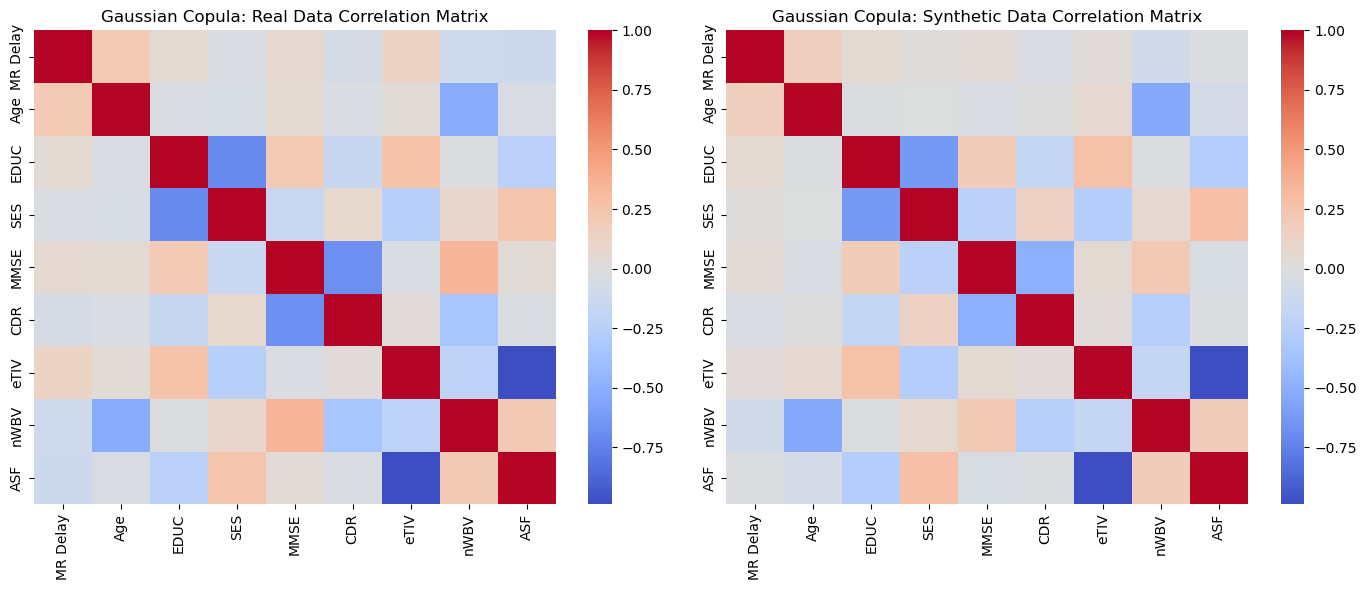

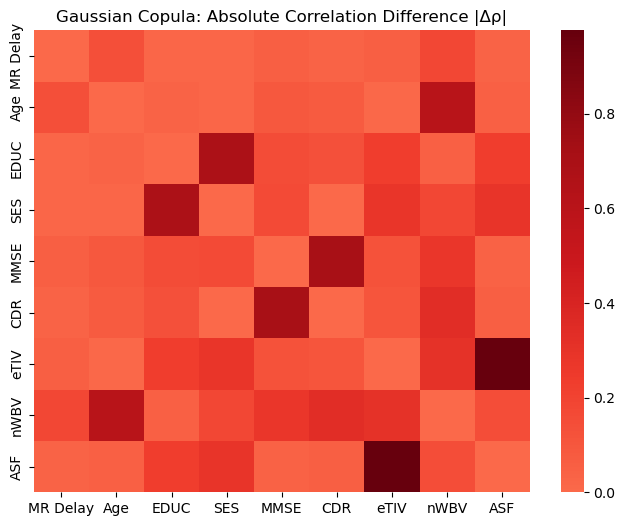

In [41]:
# Correlation heatmaps for Gaussian Copula
num_cols = [c for c in real_df_gaussiancopula.columns if c != "Group"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(real_df_gaussiancopula[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Gaussian Copula: Real Data Correlation Matrix")

sns.heatmap(synth_df_gaussiancopula[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Gaussian Copula: Synthetic Data Correlation Matrix")

plt.tight_layout()
plt.show()

diff_corr_gaussiancopula = abs(real_df_gaussiancopula[num_cols].corr() - synth_df_copulagan[num_cols].corr())
plt.figure(figsize=(8,6))
sns.heatmap(diff_corr_gaussiancopula, cmap="Reds", center=0)
plt.title("Gaussian Copula: Absolute Correlation Difference |Δρ|")
plt.show()

Gaussian Copula - Global MMD (RBF): 0.051339588139046155


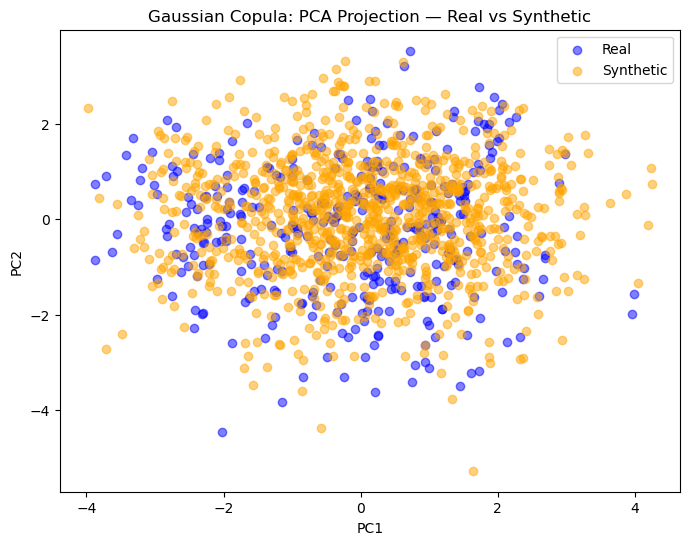

Gaussian Copula - Two-Sample Classifier Accuracy: 0.9830097087378641


In [43]:
X_real_mv_gaussiancopula = scaler_mmd_gaussiancopula.fit_transform(real_df.drop(columns=['Group']))
X_synth_mv_gaussiancopula = scaler_mmd_gaussiancopula.transform(synthetic_data_gaussiancopula.drop(columns=['Group']))

mmd_value_gaussiancopula = mmd_rbf(X_real_mv_gaussiancopula, X_synth_mv_gaussiancopula)
print(f"Gaussian Copula - Global MMD (RBF): {mmd_value_gaussiancopula}")

# PCA visualization
pca_gaussiancopula = PCA(n_components=2)
X_all_gaussiancopula = np.vstack([X_real_mv_gaussiancopula, X_synth_mv_gaussiancopula])
labels_mv_gaussiancopula = np.array(['Real'] * len(X_real_mv_gaussiancopula) + ['Synthetic'] * len(X_synth_mv_gaussiancopula))
X_pca_gaussiancopula = pca_gaussiancopula.fit_transform(X_all_gaussiancopula)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_gaussiancopula[labels_mv_gaussiancopula=='Real',0], X_pca_gaussiancopula[labels_mv_gaussiancopula=='Real',1], 
            color='blue', alpha=0.5, label='Real')
plt.scatter(X_pca_gaussiancopula[labels_mv_gaussiancopula=='Synthetic',0], X_pca_gaussiancopula[labels_mv_gaussiancopula=='Synthetic',1], 
            color='orange', alpha=0.5, label='Synthetic')
plt.title("Gaussian Copula: PCA Projection — Real vs Synthetic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# Classifier Two-Sample Test
y_real_mv_gaussiancopula = np.ones(len(X_real_mv_gaussiancopula))
y_synth_mv_gaussiancopula = np.zeros(len(X_synth_mv_gaussiancopula))
X_mv_gaussiancopula = np.vstack([X_real_mv_gaussiancopula, X_synth_mv_gaussiancopula])
y_mv_gaussiancopula = np.hstack([y_real_mv_gaussiancopula, y_synth_mv_gaussiancopula])

X_train_mv_gaussiancopula, X_test_mv_gaussiancopula, y_train_mv_gaussiancopula, y_test_mv_gaussiancopula = train_test_split(
    X_mv_gaussiancopula, y_mv_gaussiancopula, test_size=0.3, stratify=y_mv_gaussiancopula, random_state=42
)
clf_mv_gaussiancopula = RandomForestClassifier(n_estimators=200, random_state=42)
clf_mv_gaussiancopula.fit(X_train_mv_gaussiancopula, y_train_mv_gaussiancopula)
y_pred_mv_gaussiancopula = clf_mv_gaussiancopula.predict(X_test_mv_gaussiancopula)
acc_mv_gaussiancopula = accuracy_score(y_test_mv_gaussiancopula, y_pred_mv_gaussiancopula)
print(f"Gaussian Copula - Two-Sample Classifier Accuracy: {acc_mv_gaussiancopula}")

# 4. TVAE Model
The TVAE (Tabular Variational Autoencoder) synthesizer is a deep learning–based generative model designed specifically for producing high-quality synthetic tabular data. It uses a variational autoencoder (VAE) architecture that encodes real data into a lower-dimensional latent space and then decodes samples from that space back into realistic synthetic records. Unlike traditional VAEs, TVAE handles a mix of continuous and categorical features by modeling them with appropriate likelihood functions, making it well-suited for datasets like the Breast Cancer Wisconsin dataset.

In [44]:
from sdv.single_table import TVAESynthesizer

# Train TVAE model
tvae = TVAESynthesizer(metadata)
tvae.fit(real_df)
synthetic_data_tvae = tvae.sample(1000)

# Diagnostic and quality check
diagnostic_report_tvae = run_diagnostic(real_df, synthetic_data_tvae, metadata)
quality_report_tvae = evaluate_quality(real_df, synthetic_data_tvae, metadata)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 10/10 [00:00<?, ?it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 580.20it/s]|
Column Shapes Score: 81.83%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 364.79it/s]|
Column Pair Trends Score: 87.69%

Overall Score (Average): 84.76%



4.1 Kolmogorov-Smirnov (KS) Test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 482.71it/s]|
Column Shapes Score: 81.83%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 416.59it/s]|
Column Pair Trends Score: 87.69%

Overall Score (Average): 84.76%

     Column        Metric     Score
0     Group  TVComplement  0.952617
1  MR Delay  KSComplement  0.635145
2       Age  KSComplement  0.738064
3      EDUC  KSComplement  0.722188
4       SES  KSComplement  0.827925
5      MMSE  KSComplement  0.710630
6       CDR  KSComplement  0.884038
7      eTIV  KSComplement  0.929869
8      nWBV  KSComplement  0.865887
9       ASF  KSComplement  0.916641


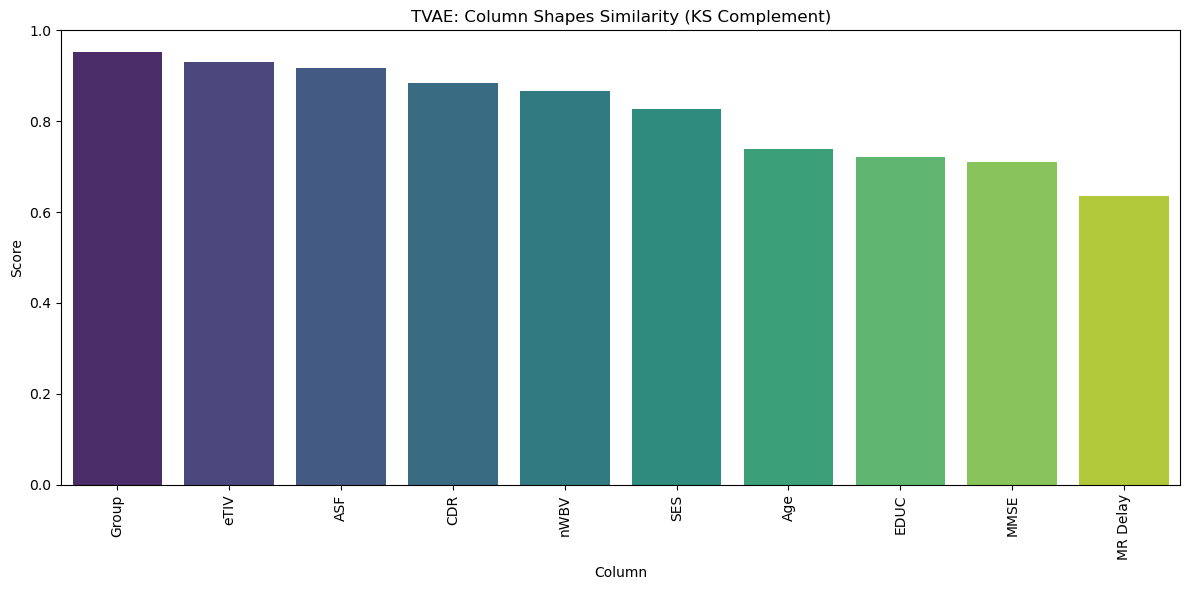

In [45]:
quality_report_tvae_ks = QualityReport()
quality_report_tvae_ks.generate(
    real_data=real_df,
    synthetic_data=synthetic_data_tvae,
    metadata=metadata.to_dict()  
)

details_tvae = quality_report_tvae_ks.get_details('Column Shapes')
print(details_tvae)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Column', y='Score',
    data=details_tvae.sort_values('Score', ascending=False),
    palette='viridis'
)
plt.title('TVAE: Column Shapes Similarity (KS Complement)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

4.2 Jensen-Shannon Divergence

    Feature  JS_Divergence
0     Group       0.001621
9       ASF       0.026355
8      nWBV       0.026393
7      eTIV       0.029453
6       CDR       0.055882
2       Age       0.074428
1  MR Delay       0.130526
3      EDUC       0.192603
4       SES       0.242303
5      MMSE       0.398089


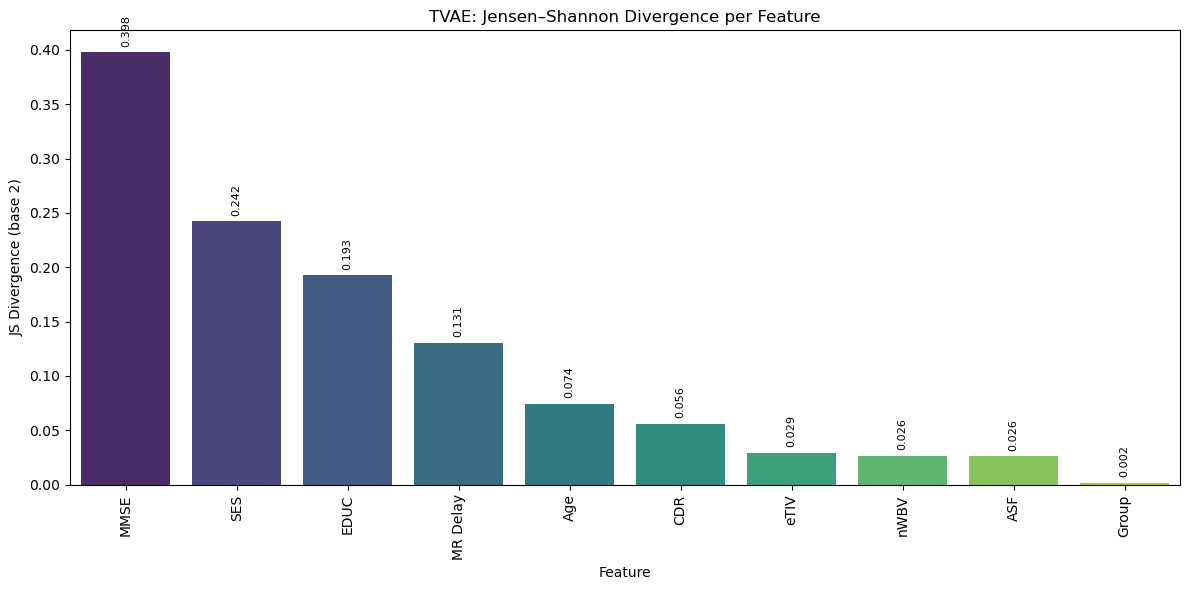

In [46]:
results_tvae_js = compute_js_divergence(real_df, synthetic_data_tvae, bins="fd", normalize=True)
print(results_tvae_js)

results_tvae_js_sorted = results_tvae_js.sort_values("JS_Divergence", ascending=False)
plt.figure(figsize=(12,6))
bars = sns.barplot(x="Feature", y="JS_Divergence", data=results_tvae_js_sorted, palette="viridis")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha="center", va="bottom", fontsize=8, rotation=90)

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("TVAE: Jensen–Shannon Divergence per Feature")
plt.tight_layout()
plt.show()

4.3 Wasserstein Distance

In [49]:
scaler_tvae = MinMaxScaler()
real_scaled_tvae = pd.DataFrame(scaler_tvae.fit_transform(real_df), columns=real_df.columns)
synthetic_scaled_tvae = pd.DataFrame(scaler_tvae.transform(synthetic_data_tvae), columns=synthetic_data_tvae.columns)

print("TVAE - Wasserstein Distance:")
for col in real_df.columns:
    dist = wasserstein_distance(real_scaled_tvae[col], synthetic_scaled_tvae[col])
    print(f"{col}: {dist:.4f}")

TVAE - Wasserstein Distance:
Group: 0.0474
MR Delay: 0.1110
Age: 0.1040
EDUC: 0.0685
SES: 0.0378
MMSE: 0.0411
CDR: 0.0442
eTIV: 0.0193
nWBV: 0.0434
ASF: 0.0224


4.4 Gower Distance

In [50]:
X_real_tvae = real_df.drop(columns=['Group'])
X_synth_tvae = synthetic_data_tvae.drop(columns=['Group'])

gower_real_tvae = 1 - gower.gower_matrix(X_real_tvae)
gower_synth_tvae = 1 - gower.gower_matrix(X_synth_tvae)
gower_cross_tvae = 1 - gower.gower_matrix(X_real_tvae, X_synth_tvae)

real_upper_tvae = gower_real_tvae[np.triu_indices_from(gower_real_tvae, k=1)]
synth_upper_tvae = gower_synth_tvae[np.triu_indices_from(gower_synth_tvae, k=1)]

max_intra_real_tvae = np.max(real_upper_tvae)
avg_intra_real_tvae = np.mean(real_upper_tvae)
max_intra_synth_tvae = np.max(synth_upper_tvae)
avg_intra_synth_tvae = np.mean(synth_upper_tvae)

cross_flat_tvae = gower_cross_tvae.flatten()
max_cross_tvae = np.max(cross_flat_tvae)
avg_cross_tvae = np.mean(cross_flat_tvae)

print("TVAE - Gower Distance:")
print("Intra-set Similarity (Real):")
print(f"Max = {max_intra_real_tvae:.4f}, Avg = {avg_intra_real_tvae:.4f}\n")
print("Intra-set Similarity (Synthetic):")
print(f"Max = {max_intra_synth_tvae:.4f}, Avg = {avg_intra_synth_tvae:.4f}\n")
print("Cross-set Similarity (Real vs Synthetic):")
print(f"Max = {max_cross_tvae:.4f}, Avg = {avg_cross_tvae:.4f}")

TVAE - Gower Distance:
Intra-set Similarity (Real):
Max = 0.9885, Avg = 0.7824

Intra-set Similarity (Synthetic):
Max = 0.9928, Avg = 0.7675

Cross-set Similarity (Real vs Synthetic):
Max = 0.9894, Avg = 0.7877


4.5 t-SNE Visualization

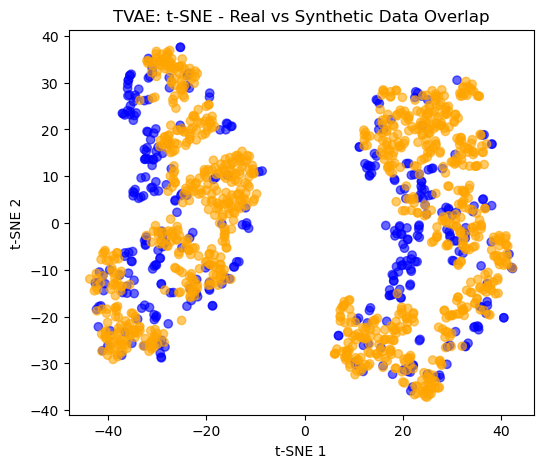

In [51]:
tsne_tvae = TSNE(n_components=2, random_state=42)
combined_tvae = np.vstack([real_scaled_tvae.values, synthetic_scaled_tvae.values])
tsne_result_tvae = tsne_tvae.fit_transform(combined_tvae)
labels_tvae = ['Real'] * len(real_scaled_tvae) + ['Synthetic'] * len(synthetic_scaled_tvae)

plt.figure(figsize=(6,5))
plt.scatter(tsne_result_tvae[:, 0], tsne_result_tvae[:, 1],
            c=['blue' if l == 'Real' else 'orange' for l in labels_tvae],
            alpha=0.6)
plt.title("TVAE: t-SNE - Real vs Synthetic Data Overlap")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

4.6 MMD (Maximum Mean Discrepancy)

In [52]:
scaler_mmd_tvae = StandardScaler()
real_scaled_mmd_tvae = scaler_mmd_tvae.fit_transform(real_df.drop(columns=['Group']))
synthetic_scaled_mmd_tvae = scaler_mmd_tvae.transform(synthetic_data_tvae.drop(columns=['Group']))

mmd_score_tvae = compute_mmd(real_scaled_mmd_tvae, synthetic_scaled_mmd_tvae)
print(f"TVAE - MMD score: {mmd_score_tvae:.4f}")

TVAE - MMD score: 0.0412


4.7 Cosine Similarity

In [53]:
cross_sim_tvae = cosine_similarity(real_scaled_mmd_tvae, synthetic_scaled_mmd_tvae)
avg_sim_tvae = np.mean(cross_sim_tvae)
max_sim_tvae = np.max(cross_sim_tvae)

print("TVAE - Sample-Level Similarity:")
print(f"Average cosine similarity: {avg_sim_tvae:.4f}")
print(f"Maximum cosine similarity: {max_sim_tvae:.4f}")

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0116
Maximum cosine similarity: 0.9968


4.8 Privacy Check

In [54]:
nn_tvae = NearestNeighbors(n_neighbors=1).fit(real_scaled_mmd_tvae)
distances_tvae, _ = nn_tvae.kneighbors(synthetic_scaled_mmd_tvae)
avg_nn_dist_tvae = np.mean(distances_tvae)

print("TVAE - Privacy Check:")
print(f"Average Nearest Neighbor Distance (Synthetic → Real): {avg_nn_dist_tvae:.4f}")

TVAE - Privacy Check:
Average Nearest Neighbor Distance (Synthetic → Real): 1.2851


4.10 Bivariate Analysis

In [55]:
real_df_tvae = real_df
synth_df_tvae = synthetic_data_tvae
synth_df_tvae = synth_df_tvae[real_df_tvae.columns]

corr_results_tvae, target_results_tvae = bivariate_quality_ad(
    real_df=real_df_tvae, 
    synth_df=synth_df_tvae
)

print("TVAE - Largest differences in pairwise correlations:")
print(corr_results_tvae.head(10))
print('================================')
print("TVAE - Features that differ most by diagnosis class:")
print(target_results_tvae.head(10))

TVAE - Largest differences in pairwise correlations:
       var_a var_b  delta_corr
1   MR Delay  EDUC    0.487389
2   MR Delay   SES    0.380955
34      eTIV   ASF    0.326025
20      EDUC   ASF    0.236587
6   MR Delay  nWBV    0.220488
18      EDUC  eTIV    0.198030
23       SES  eTIV    0.195685
8        Age  EDUC    0.195098
26      MMSE   CDR    0.193517
7   MR Delay   ASF    0.193041
TVAE - Features that differ most by diagnosis class:
    feature  delta_wasserstein
3       SES           0.109322
5       CDR           0.102887
4      MMSE           0.069585
7      nWBV           0.040078
2      EDUC           0.019965
8       ASF           0.013375
0  MR Delay           0.012148
6      eTIV           0.010907
1       Age           0.010704


4.11 Multivariate Analysis

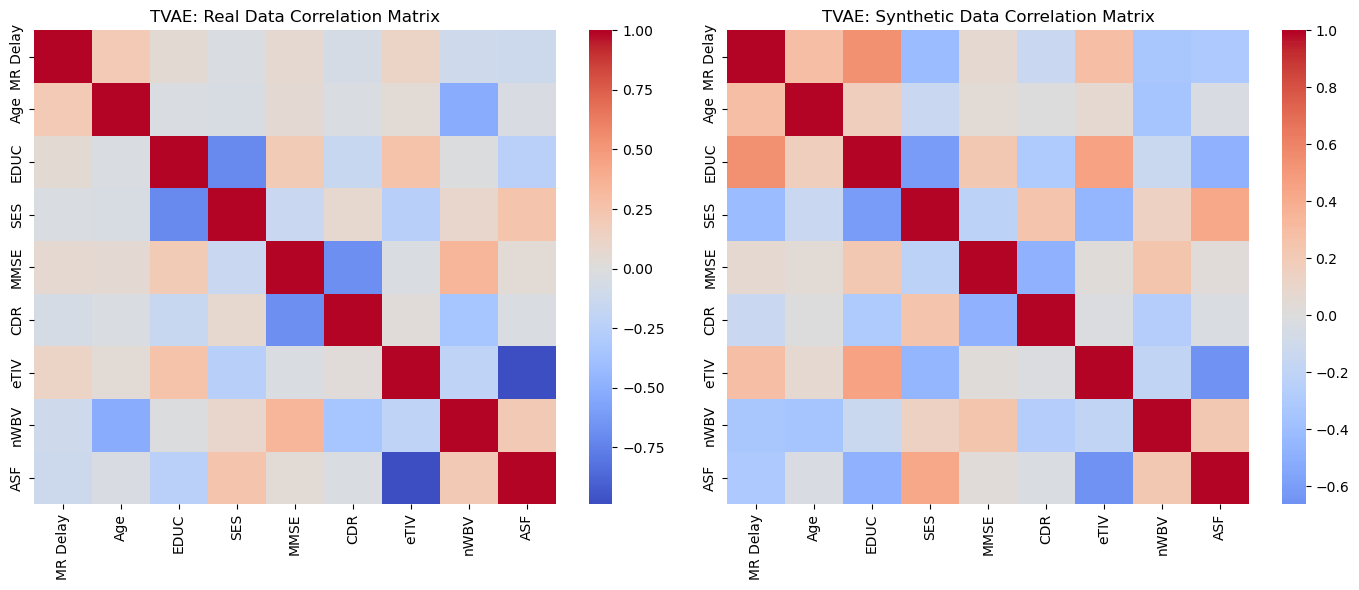

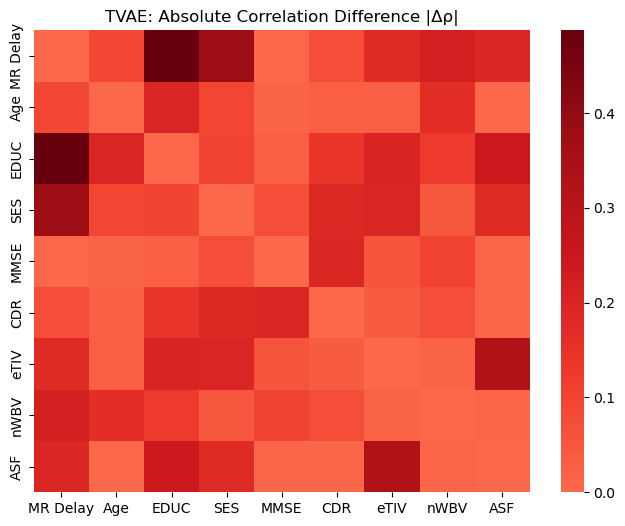

In [56]:
# Correlation heatmaps for TVAE
num_cols = [c for c in real_df_tvae.columns if c != "Group"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(real_df_tvae[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("TVAE: Real Data Correlation Matrix")

sns.heatmap(synth_df_tvae[num_cols].corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("TVAE: Synthetic Data Correlation Matrix")

plt.tight_layout()
plt.show()

diff_corr_tvae = abs(real_df_tvae[num_cols].corr() - synth_df_tvae[num_cols].corr())
plt.figure(figsize=(8,6))
sns.heatmap(diff_corr_tvae, cmap="Reds", center=0)
plt.title("TVAE: Absolute Correlation Difference |Δρ|")
plt.show()

TVAE - Global MMD (RBF): 0.031236729470115465


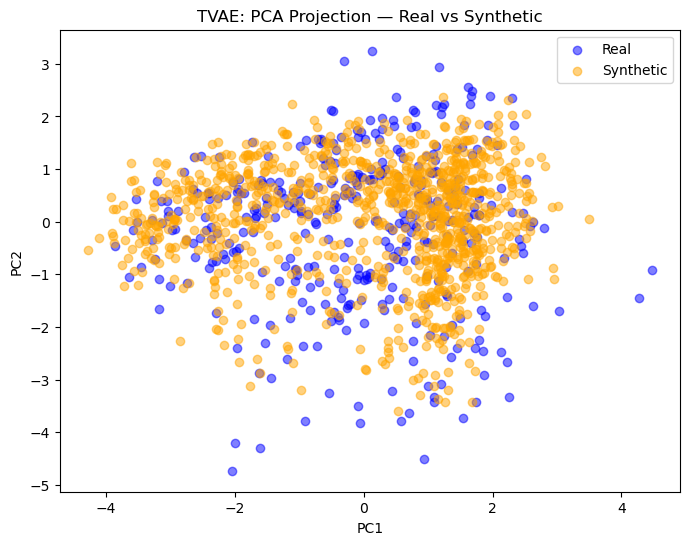

TVAE - Two-Sample Classifier Accuracy: 0.9538834951456311


In [57]:
X_real_mv_tvae = scaler_mmd_tvae.fit_transform(real_df.drop(columns=['Group']))
X_synth_mv_tvae = scaler_mmd_tvae.transform(synthetic_data_tvae.drop(columns=['Group']))

mmd_value_tvae = mmd_rbf(X_real_mv_tvae, X_synth_mv_tvae)
print(f"TVAE - Global MMD (RBF): {mmd_value_tvae}")

# PCA visualization
pca_tvae = PCA(n_components=2)
X_all_tvae = np.vstack([X_real_mv_tvae, X_synth_mv_tvae])
labels_mv_tvae = np.array(['Real'] * len(X_real_mv_tvae) + ['Synthetic'] * len(X_synth_mv_tvae))
X_pca_tvae = pca_tvae.fit_transform(X_all_tvae)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_tvae[labels_mv_tvae=='Real',0], X_pca_tvae[labels_mv_tvae=='Real',1], 
            color='blue', alpha=0.5, label='Real')
plt.scatter(X_pca_tvae[labels_mv_tvae=='Synthetic',0], X_pca_tvae[labels_mv_tvae=='Synthetic',1], 
            color='orange', alpha=0.5, label='Synthetic')
plt.title("TVAE: PCA Projection — Real vs Synthetic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# Classifier Two-Sample Test
y_real_mv_tvae = np.ones(len(X_real_mv_tvae))
y_synth_mv_tvae = np.zeros(len(X_synth_mv_tvae))
X_mv_tvae = np.vstack([X_real_mv_tvae, X_synth_mv_tvae])
y_mv_tvae = np.hstack([y_real_mv_tvae, y_synth_mv_tvae])

X_train_mv_tvae, X_test_mv_tvae, y_train_mv_tvae, y_test_mv_tvae = train_test_split(
    X_mv_tvae, y_mv_tvae, test_size=0.3, stratify=y_mv_tvae, random_state=42
)
clf_mv_tvae = RandomForestClassifier(n_estimators=200, random_state=42)
clf_mv_tvae.fit(X_train_mv_tvae, y_train_mv_tvae)
y_pred_mv_tvae = clf_mv_tvae.predict(X_test_mv_tvae)
acc_mv_tvae = accuracy_score(y_test_mv_tvae, y_pred_mv_tvae)
print(f"TVAE - Two-Sample Classifier Accuracy: {acc_mv_tvae}")

# 5. Utility with 10 classifiers

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = { 

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_models(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    # Split TRAIN df -> (train part only)  (we don’t need train_df's test split)
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    # Split TEST df -> (test part only)
    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    # Scale using TRAIN statistics only
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)

        y_pred = clf.predict(X_test_s)

        # AUC needs probabilities (or decision_function); handle both safely
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            # convert to 0-1-ish range (not perfect prob, but works for AUC)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)

        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

Guassian Copula

In [60]:
label_col = "Group"

tstr_results_gc = evaluate_models(
    train_df=synthetic_data_gaussiancopula,
    test_df=real_df,
    label_col=label_col,
    models=models
)

print("Gaussian Copula - TSTR (Train Synth, Test Real)")
display(tstr_results_gc)

print('==================================================')

trtr_results = evaluate_models(
    train_df=real_df,
    test_df=real_df,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)


print('==================================================')

comparison = trtr_results.merge(
    tstr_results_gc, on="Model", suffixes=("_TRTR", "_TSTR")
)

comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
comparison = comparison.sort_values("AUC_Drop", ascending=False)

display(comparison)

Gaussian Copula - TSTR (Train Synth, Test Real)


,Model,Accuracy,F1,AUC
0,LogReg,0.933333,0.927536,0.953058
8,AdaBoost,0.880000,0.876712,0.952703
6,ExtraTrees,0.840000,0.850000,0.935277
7,GradientBoost,0.746667,0.786517,0.933144
5,RandomForest,0.826667,0.839506,0.930654
9,MLP,0.760000,0.785714,0.908250
3,NaiveBayes,0.893333,0.878788,0.894026
1,SVM-RBF,0.773333,0.784810,0.883713
2,KNN,0.746667,0.746667,0.800142
4,DecisionTree,0.600000,0.700000,0.604552


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
0,LogReg,0.960000,0.957746,0.985775
9,MLP,0.960000,0.957746,0.975107
7,GradientBoost,0.960000,0.957746,0.971550
8,AdaBoost,0.960000,0.957746,0.967994
6,ExtraTrees,0.960000,0.957746,0.967639
3,NaiveBayes,0.960000,0.957746,0.963727
5,RandomForest,0.960000,0.957746,0.956259
2,KNN,0.893333,0.878788,0.954836
1,SVM-RBF,0.960000,0.957746,0.948080
4,DecisionTree,0.946667,0.944444,0.946302


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop
9,DecisionTree,0.946667,0.944444,0.946302,0.600000,0.700000,0.604552,0.341750
7,KNN,0.893333,0.878788,0.954836,0.746667,0.746667,0.800142,0.154694
5,NaiveBayes,0.960000,0.957746,0.963727,0.893333,0.878788,0.894026,0.069701
1,MLP,0.960000,0.957746,0.975107,0.760000,0.785714,0.908250,0.066856
8,SVM-RBF,0.960000,0.957746,0.948080,0.773333,0.784810,0.883713,0.064367
2,GradientBoost,0.960000,0.957746,0.971550,0.746667,0.786517,0.933144,0.038407
0,LogReg,0.960000,0.957746,0.985775,0.933333,0.927536,0.953058,0.032717
4,ExtraTrees,0.960000,0.957746,0.967639,0.840000,0.850000,0.935277,0.032361
6,RandomForest,0.960000,0.957746,0.956259,0.826667,0.839506,0.930654,0.025605
3,AdaBoost,0.960000,0.957746,0.967994,0.880000,0.876712,0.952703,0.015292


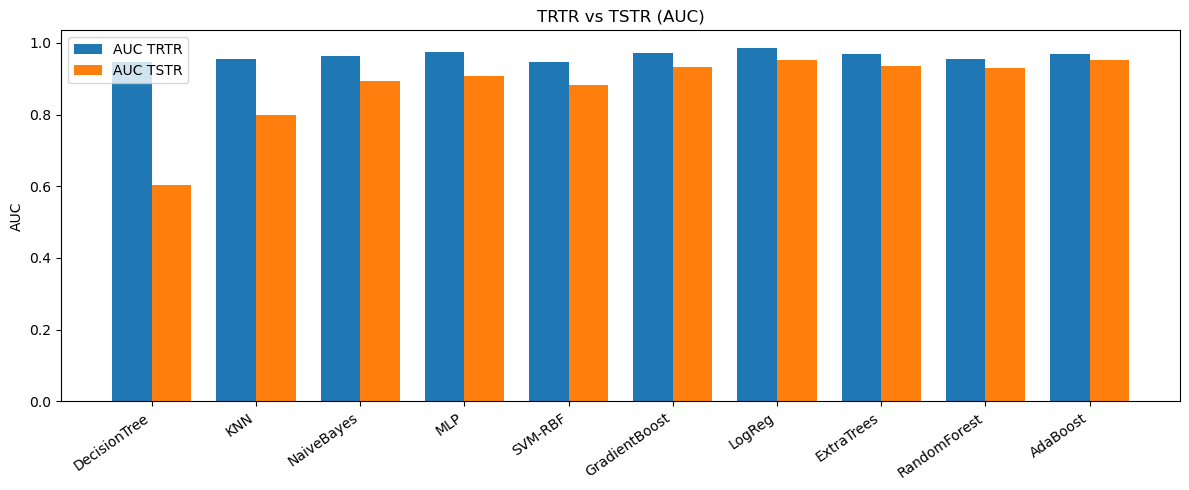

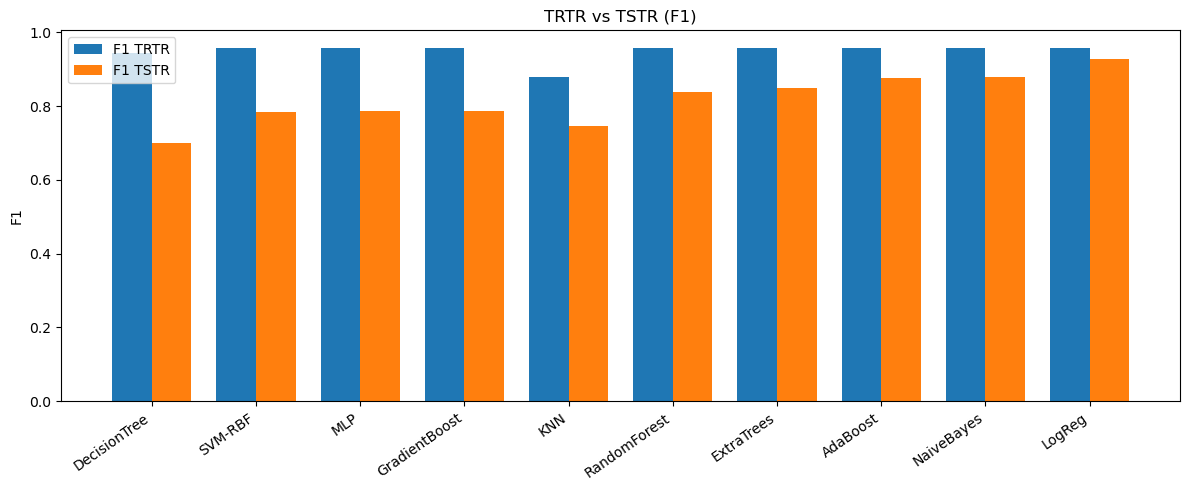

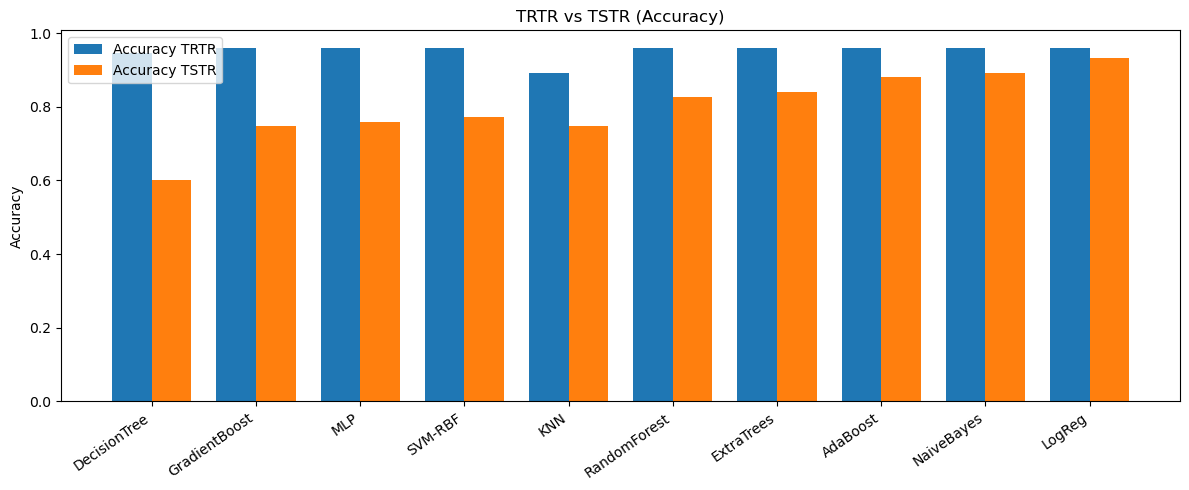

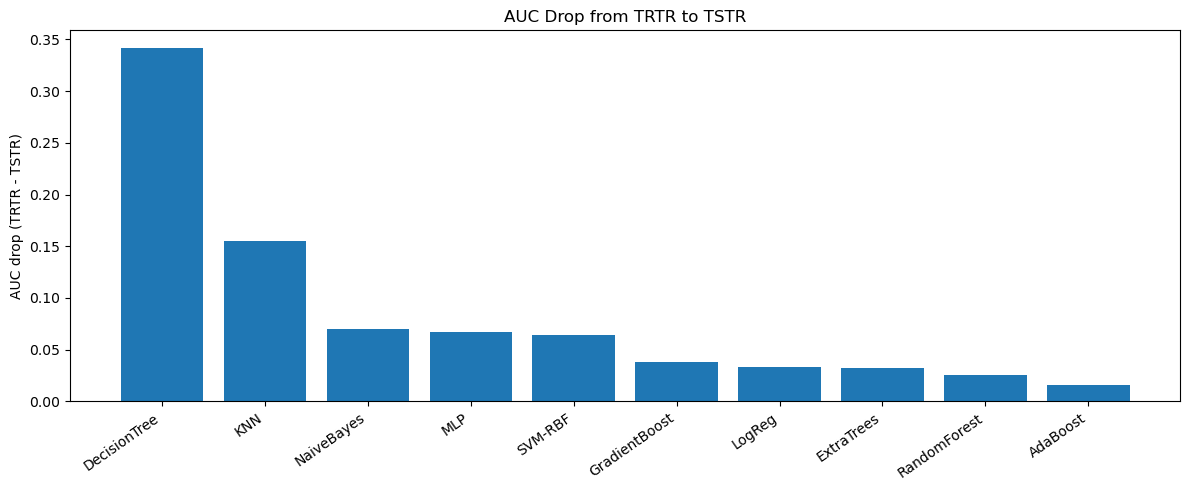

In [61]:
import matplotlib.pyplot as plt 

def plot_trtr_vs_tstr(trtr_results, tstr_results, metric='AUC'):
    df = trtr_results[['Model', metric]].merge(
        tstr_results[['Model', metric]], on='Model', suffixes = ("_TRTR", "_TSTR"))
    
    df['Drop'] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values('Drop', ascending = False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12,5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df):
    df = comparison_df.sort_values("AUC_Drop", ascending=False)

    x = np.arange(len(df))
    plt.figure(figsize=(12,5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title("AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show() 
      
plot_trtr_vs_tstr(trtr_results, tstr_results_gc, metric="AUC")
plot_trtr_vs_tstr(trtr_results, tstr_results_gc, metric="F1")
plot_trtr_vs_tstr(trtr_results, tstr_results_gc, metric="Accuracy")

plot_auc_drop(comparison)

In [62]:
def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models = [m for m in trtr.index if m in tstr.index]

    n = len(models)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.05)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    # Hide unused subplots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} — TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalisation gap (TRTR − TSTR)",
        fontsize=14
    )

    plt.show()

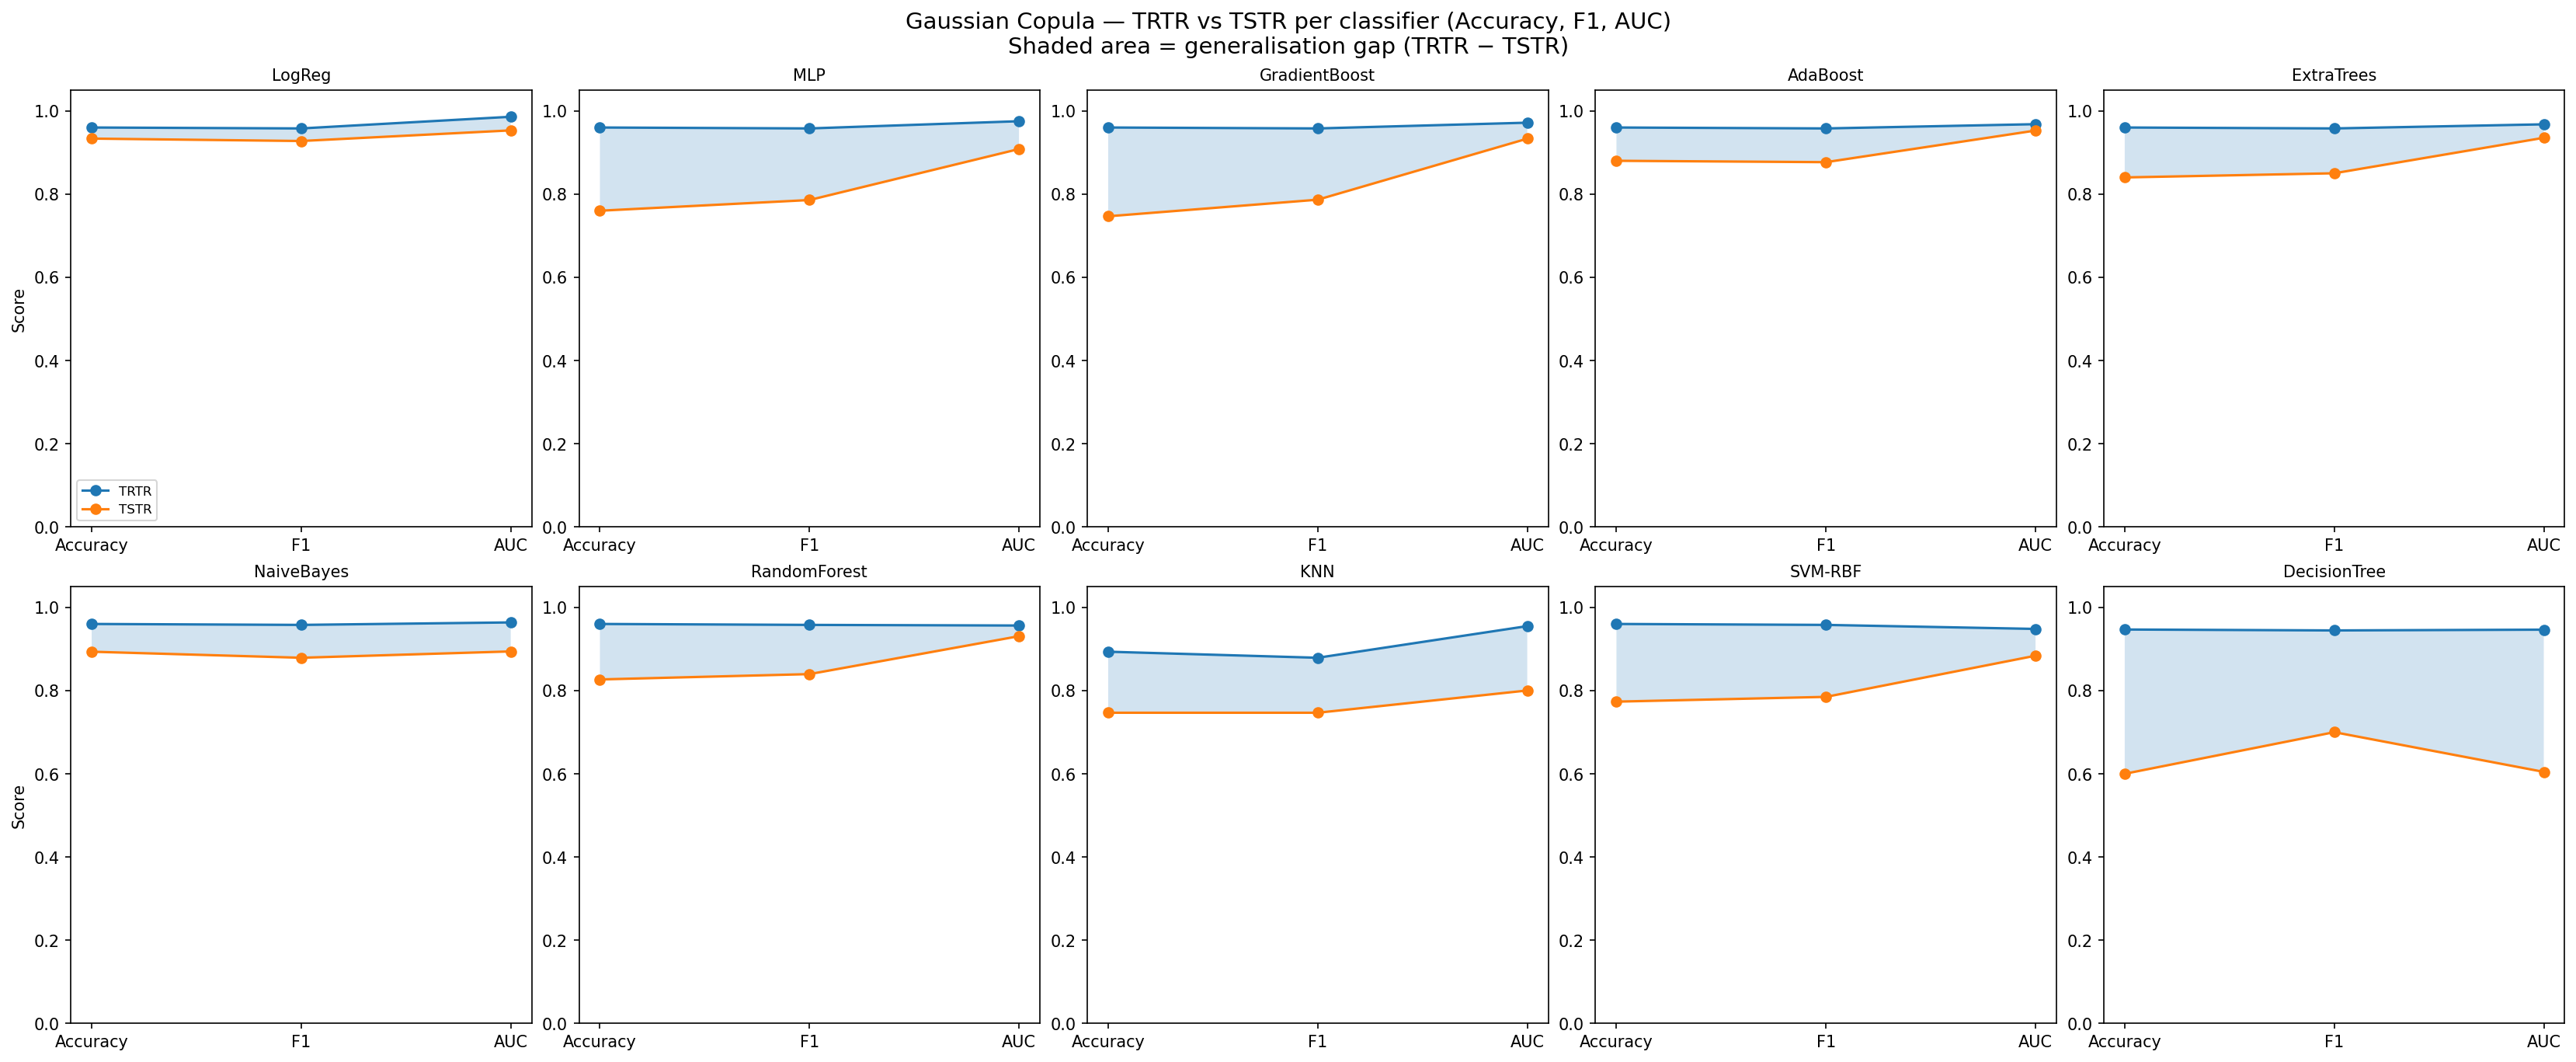

In [63]:
plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results_gc,
    generator_name="Gaussian Copula",
    ncols=5
)

CTGAN

CTGAN - TSTR (Train Synth, Test Real)


,Model,Accuracy,F1,AUC
3,NaiveBayes,0.760000,0.678571,0.926031
0,LogReg,0.760000,0.689655,0.899716
6,ExtraTrees,0.760000,0.756757,0.839260
5,RandomForest,0.733333,0.722222,0.828592
1,SVM-RBF,0.693333,0.622951,0.822902
8,AdaBoost,0.746667,0.716418,0.816501
7,GradientBoost,0.680000,0.612903,0.736842
4,DecisionTree,0.733333,0.714286,0.732575
2,KNN,0.666667,0.637681,0.657183
9,MLP,0.546667,0.527778,0.569701


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
0,LogReg,0.960000,0.957746,0.985775
9,MLP,0.960000,0.957746,0.975107
7,GradientBoost,0.960000,0.957746,0.971550
8,AdaBoost,0.960000,0.957746,0.967994
6,ExtraTrees,0.960000,0.957746,0.967639
3,NaiveBayes,0.960000,0.957746,0.963727
5,RandomForest,0.960000,0.957746,0.956259
2,KNN,0.893333,0.878788,0.954836
1,SVM-RBF,0.960000,0.957746,0.948080
4,DecisionTree,0.946667,0.944444,0.946302


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop
1,MLP,0.960000,0.957746,0.975107,0.546667,0.527778,0.569701,0.405405
7,KNN,0.893333,0.878788,0.954836,0.666667,0.637681,0.657183,0.297653
2,GradientBoost,0.960000,0.957746,0.971550,0.680000,0.612903,0.736842,0.234708
9,DecisionTree,0.946667,0.944444,0.946302,0.733333,0.714286,0.732575,0.213727
3,AdaBoost,0.960000,0.957746,0.967994,0.746667,0.716418,0.816501,0.151494
4,ExtraTrees,0.960000,0.957746,0.967639,0.760000,0.756757,0.839260,0.128378
6,RandomForest,0.960000,0.957746,0.956259,0.733333,0.722222,0.828592,0.127667
8,SVM-RBF,0.960000,0.957746,0.948080,0.693333,0.622951,0.822902,0.125178
0,LogReg,0.960000,0.957746,0.985775,0.760000,0.689655,0.899716,0.086060
5,NaiveBayes,0.960000,0.957746,0.963727,0.760000,0.678571,0.926031,0.037696


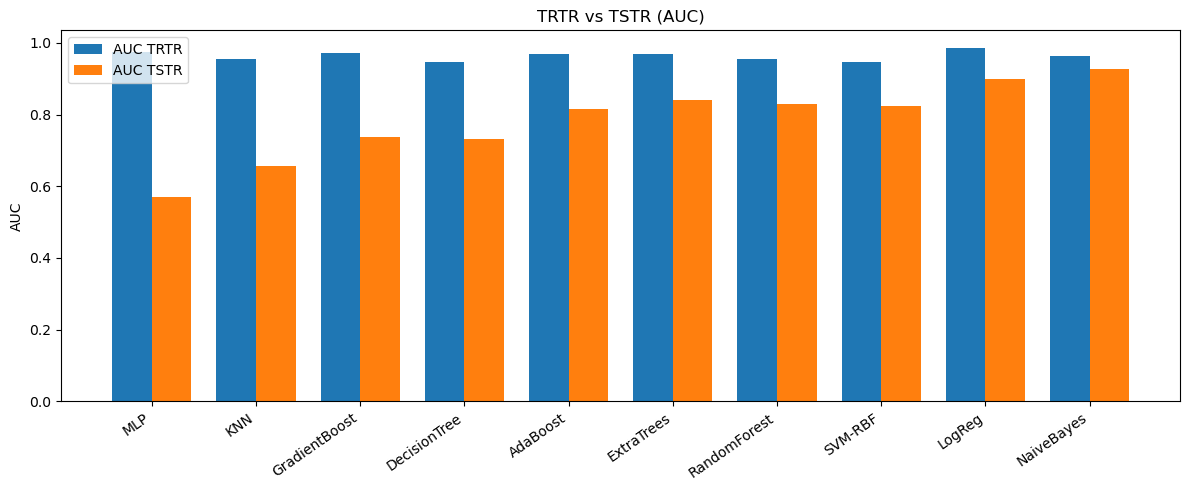

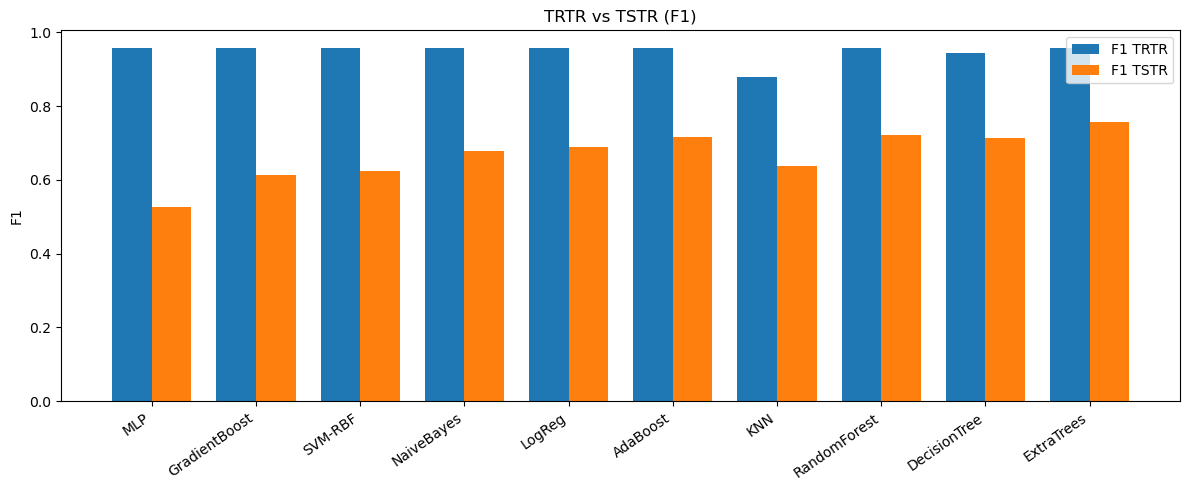

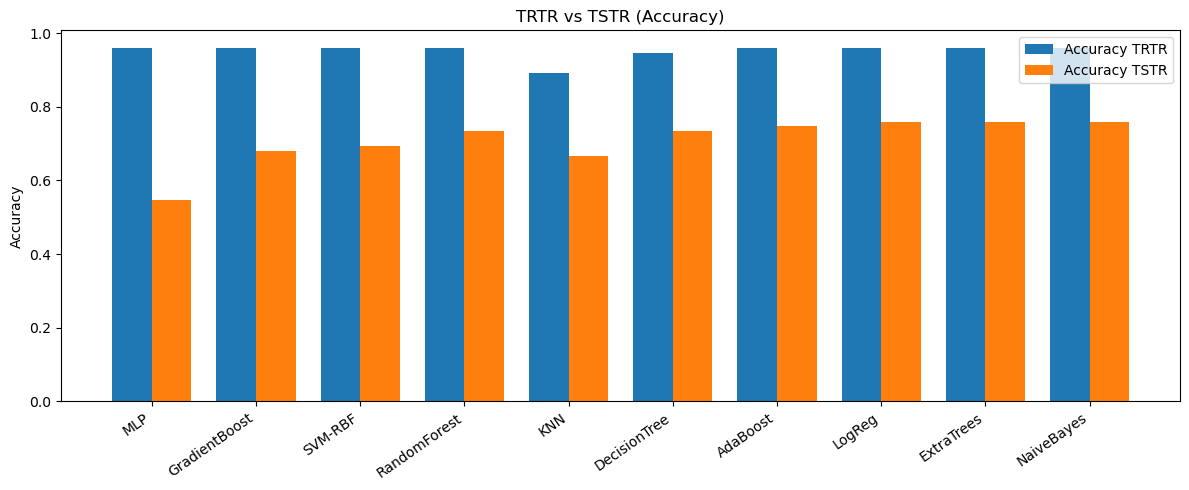

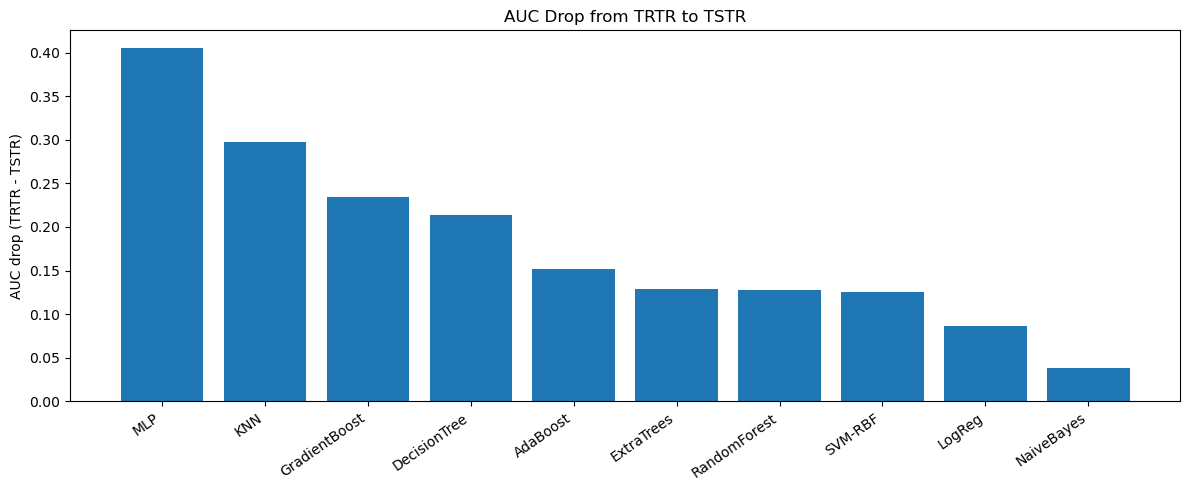

In [64]:
label_col = "Group"

tstr_results_ctgan = evaluate_models(
    train_df=synthetic_data_ctgan,
    test_df=real_df,
    label_col=label_col,
    models=models
)

print("CTGAN - TSTR (Train Synth, Test Real)")
display(tstr_results_ctgan)

print('==================================================')

trtr_results = evaluate_models(
    train_df=real_df,
    test_df=real_df,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)


print('==================================================')

comparison = trtr_results.merge(
    tstr_results_ctgan, on="Model", suffixes=("_TRTR", "_TSTR")
)

comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
comparison = comparison.sort_values("AUC_Drop", ascending=False)

display(comparison)

plot_trtr_vs_tstr(trtr_results, tstr_results_ctgan, metric="AUC")
plot_trtr_vs_tstr(trtr_results, tstr_results_ctgan, metric="F1")
plot_trtr_vs_tstr(trtr_results, tstr_results_ctgan, metric="Accuracy")

plot_auc_drop(comparison)

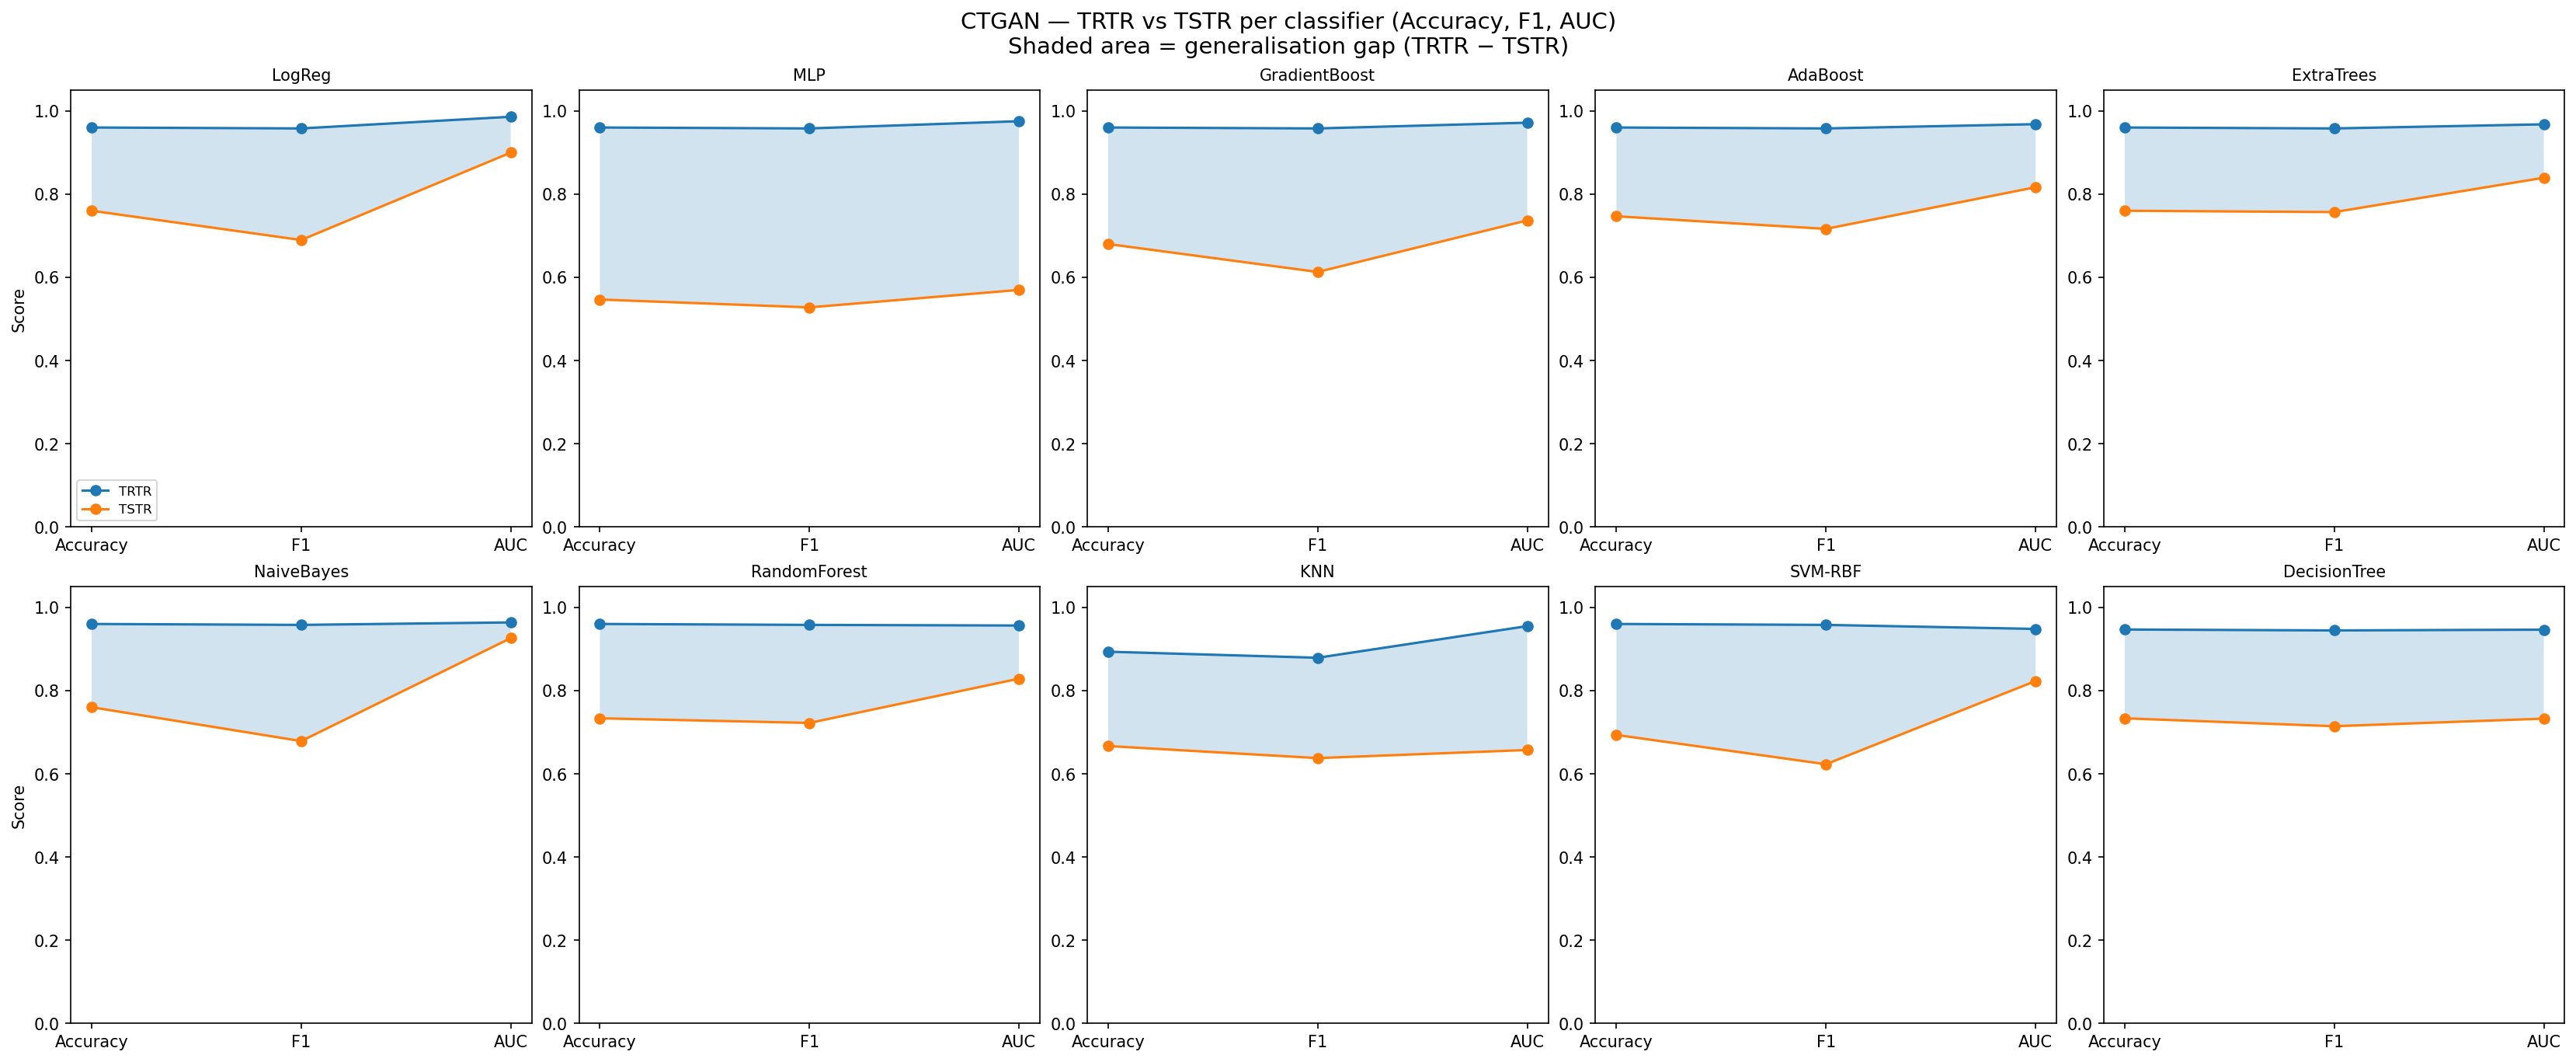

In [65]:
plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results_ctgan,
    generator_name="CTGAN",
    ncols=5
)

Copula GAN

CopulaGAN - TSTR (Train Synth, Test Real)


,Model,Accuracy,F1,AUC
3,NaiveBayes,0.760000,0.678571,0.926031
0,LogReg,0.760000,0.689655,0.899716
6,ExtraTrees,0.760000,0.756757,0.839260
5,RandomForest,0.733333,0.722222,0.828592
1,SVM-RBF,0.693333,0.622951,0.822902
8,AdaBoost,0.746667,0.716418,0.816501
7,GradientBoost,0.680000,0.612903,0.736842
4,DecisionTree,0.733333,0.714286,0.732575
2,KNN,0.666667,0.637681,0.657183
9,MLP,0.546667,0.527778,0.569701


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
0,LogReg,0.960000,0.957746,0.985775
9,MLP,0.960000,0.957746,0.975107
7,GradientBoost,0.960000,0.957746,0.971550
8,AdaBoost,0.960000,0.957746,0.967994
6,ExtraTrees,0.960000,0.957746,0.967639
3,NaiveBayes,0.960000,0.957746,0.963727
5,RandomForest,0.960000,0.957746,0.956259
2,KNN,0.893333,0.878788,0.954836
1,SVM-RBF,0.960000,0.957746,0.948080
4,DecisionTree,0.946667,0.944444,0.946302


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop
7,KNN,0.893333,0.878788,0.954836,0.586667,0.575342,0.592461,0.362376
9,DecisionTree,0.946667,0.944444,0.946302,0.600000,0.571429,0.599218,0.347084
0,LogReg,0.960000,0.957746,0.985775,0.720000,0.727273,0.753912,0.231863
5,NaiveBayes,0.960000,0.957746,0.963727,0.693333,0.656716,0.753201,0.210526
8,SVM-RBF,0.960000,0.957746,0.948080,0.640000,0.619718,0.741821,0.206259
2,GradientBoost,0.960000,0.957746,0.971550,0.720000,0.727273,0.766003,0.205548
4,ExtraTrees,0.960000,0.957746,0.967639,0.760000,0.763158,0.822902,0.144737
1,MLP,0.960000,0.957746,0.975107,0.786667,0.789474,0.849218,0.125889
3,AdaBoost,0.960000,0.957746,0.967994,0.813333,0.815789,0.867354,0.100640
6,RandomForest,0.960000,0.957746,0.956259,0.853333,0.849315,0.865220,0.091038


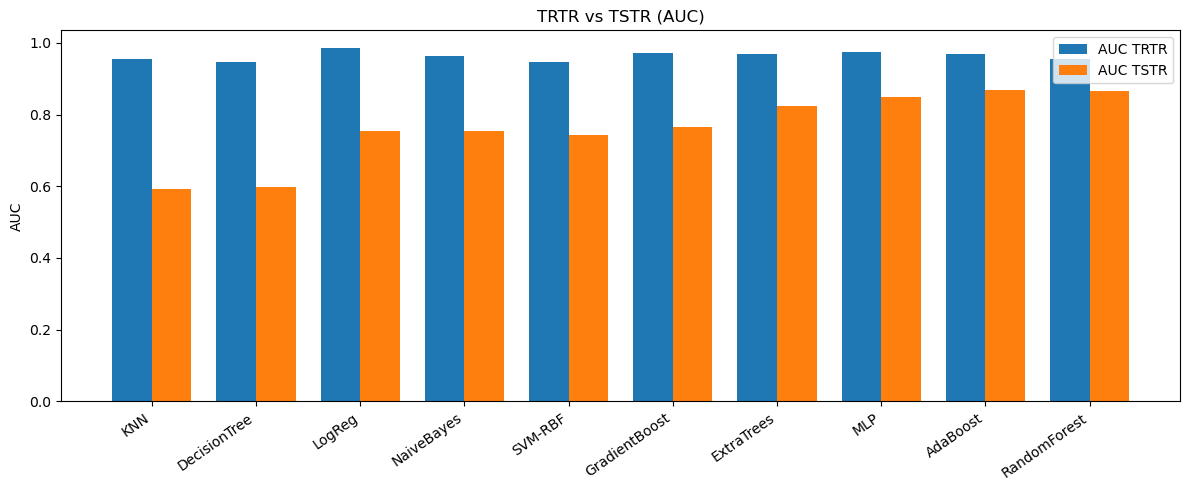

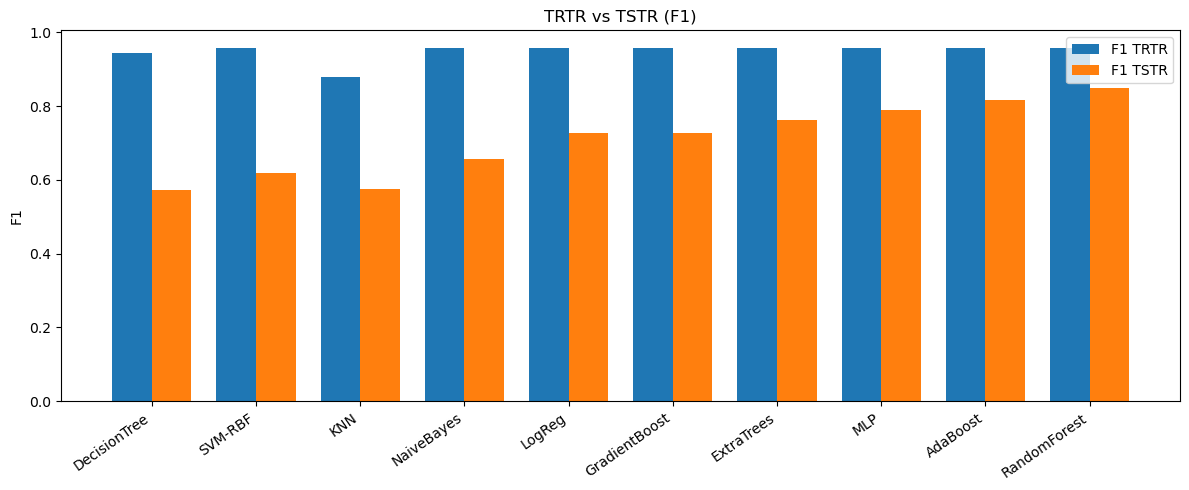

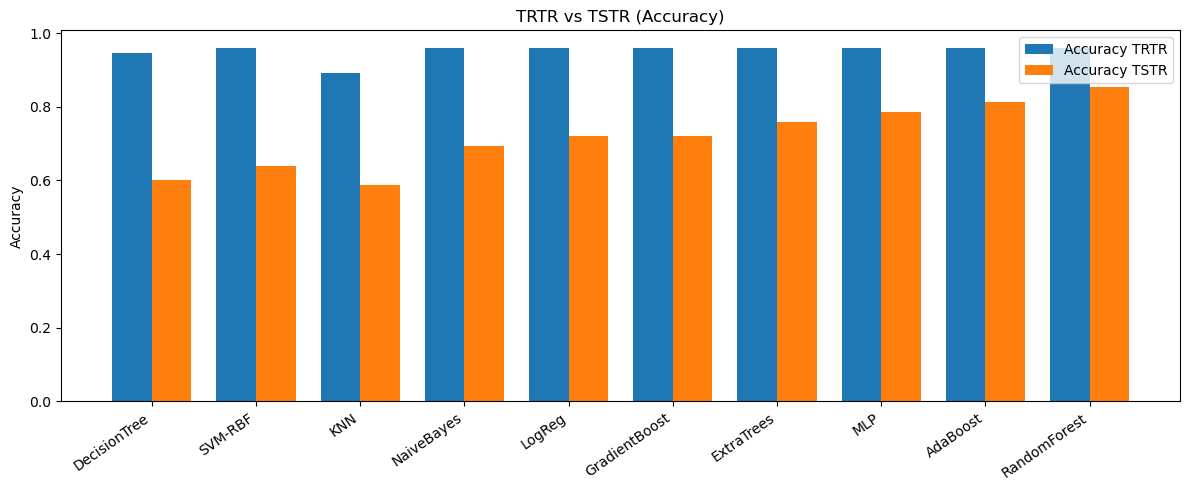

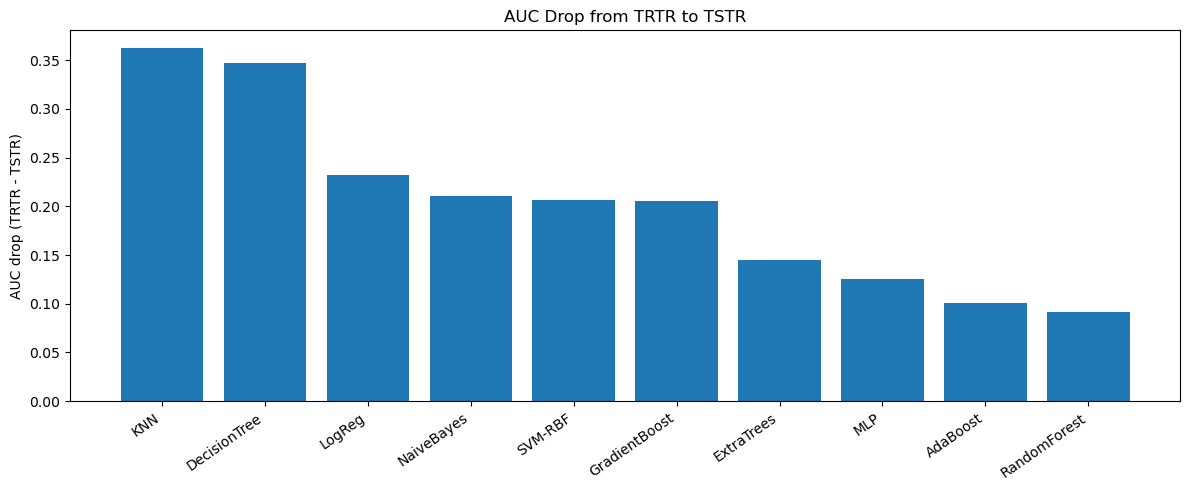

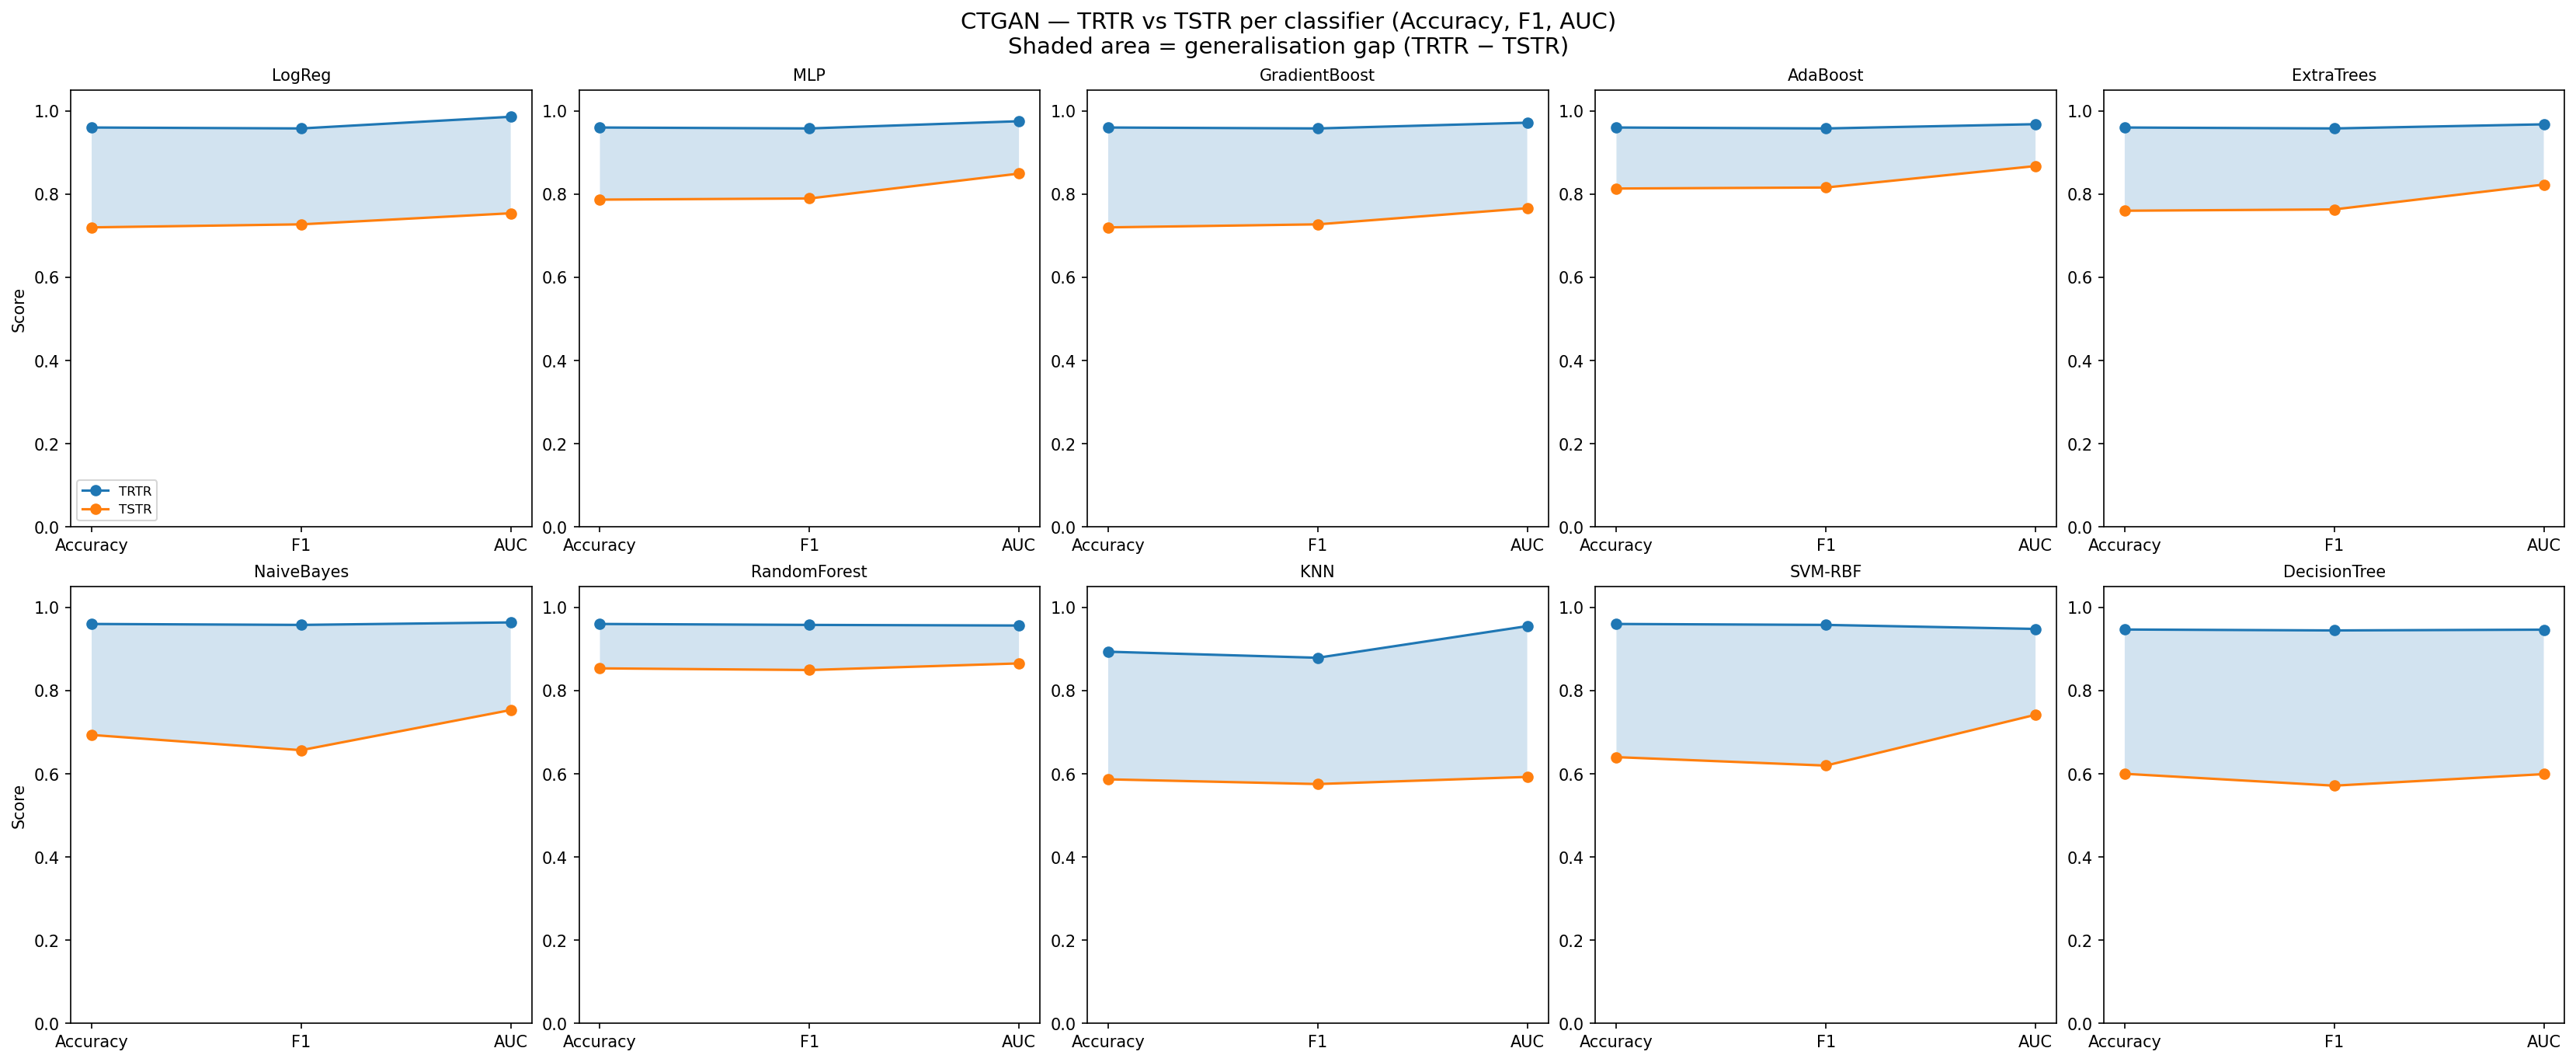

In [66]:
label_col = "Group"

tstr_results_copulagan = evaluate_models(
    train_df=synthetic_data_copulagan,
    test_df=real_df,
    label_col=label_col,
    models=models
)

print("CopulaGAN - TSTR (Train Synth, Test Real)")
display(tstr_results_ctgan)

print('==================================================')

trtr_results = evaluate_models(
    train_df=real_df,
    test_df=real_df,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)


print('==================================================')

comparison = trtr_results.merge(
    tstr_results_copulagan, on="Model", suffixes=("_TRTR", "_TSTR")
)

comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
comparison = comparison.sort_values("AUC_Drop", ascending=False)

display(comparison)

plot_trtr_vs_tstr(trtr_results, tstr_results_copulagan, metric="AUC")
plot_trtr_vs_tstr(trtr_results, tstr_results_copulagan, metric="F1")
plot_trtr_vs_tstr(trtr_results, tstr_results_copulagan, metric="Accuracy")

plot_auc_drop(comparison)

plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results_copulagan,
    generator_name="CTGAN",
    ncols=5
)

CopulaGAN - TSTR (Train Synth, Test Real)


,Model,Accuracy,F1,AUC
8,AdaBoost,0.946667,0.945946,0.993243
7,GradientBoost,0.920000,0.921053,0.983642
6,ExtraTrees,0.946667,0.945946,0.982930
5,RandomForest,0.906667,0.909091,0.980797
9,MLP,0.946667,0.945946,0.977952
0,LogReg,0.920000,0.918919,0.977952
3,NaiveBayes,0.960000,0.957746,0.968706
1,SVM-RBF,0.946667,0.942857,0.965149
2,KNN,0.906667,0.904110,0.956615
4,DecisionTree,0.786667,0.809524,0.788407


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
0,LogReg,0.960000,0.957746,0.985775
9,MLP,0.960000,0.957746,0.975107
7,GradientBoost,0.960000,0.957746,0.971550
8,AdaBoost,0.960000,0.957746,0.967994
6,ExtraTrees,0.960000,0.957746,0.967639
3,NaiveBayes,0.960000,0.957746,0.963727
5,RandomForest,0.960000,0.957746,0.956259
2,KNN,0.893333,0.878788,0.954836
1,SVM-RBF,0.960000,0.957746,0.948080
4,DecisionTree,0.946667,0.944444,0.946302


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop
9,DecisionTree,0.946667,0.944444,0.946302,0.786667,0.809524,0.788407,0.157895
0,LogReg,0.960000,0.957746,0.985775,0.920000,0.918919,0.977952,0.007824
7,KNN,0.893333,0.878788,0.954836,0.906667,0.904110,0.956615,-0.001778
1,MLP,0.960000,0.957746,0.975107,0.946667,0.945946,0.977952,-0.002845
5,NaiveBayes,0.960000,0.957746,0.963727,0.960000,0.957746,0.968706,-0.004979
2,GradientBoost,0.960000,0.957746,0.971550,0.920000,0.921053,0.983642,-0.012091
4,ExtraTrees,0.960000,0.957746,0.967639,0.946667,0.945946,0.982930,-0.015292
8,SVM-RBF,0.960000,0.957746,0.948080,0.946667,0.942857,0.965149,-0.017070
6,RandomForest,0.960000,0.957746,0.956259,0.906667,0.909091,0.980797,-0.024538
3,AdaBoost,0.960000,0.957746,0.967994,0.946667,0.945946,0.993243,-0.025249


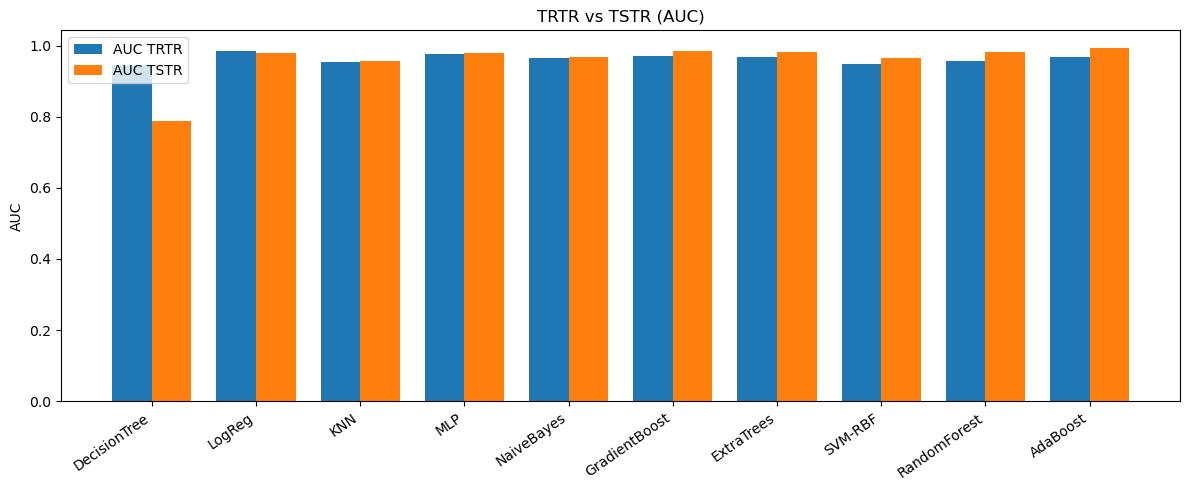

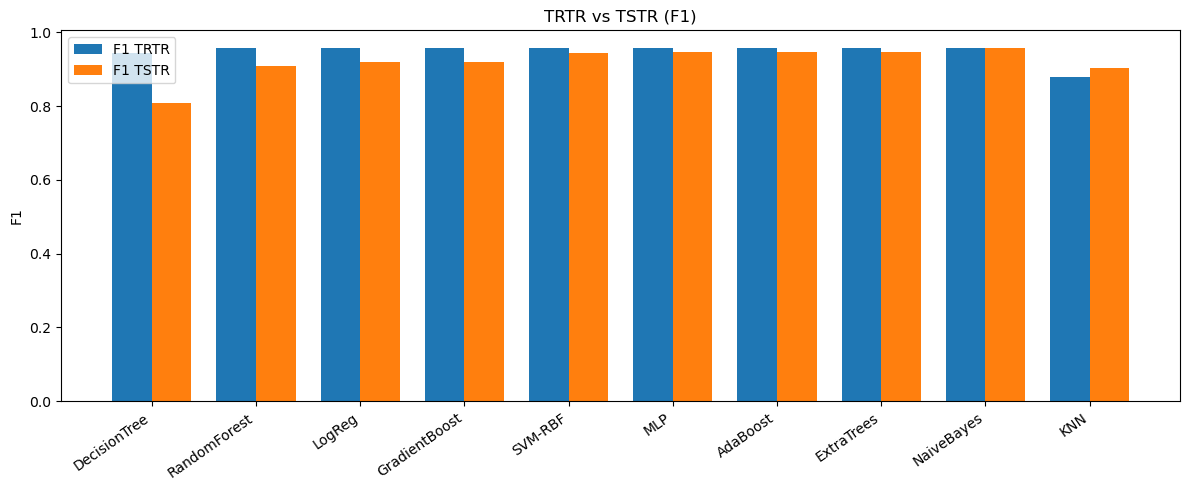

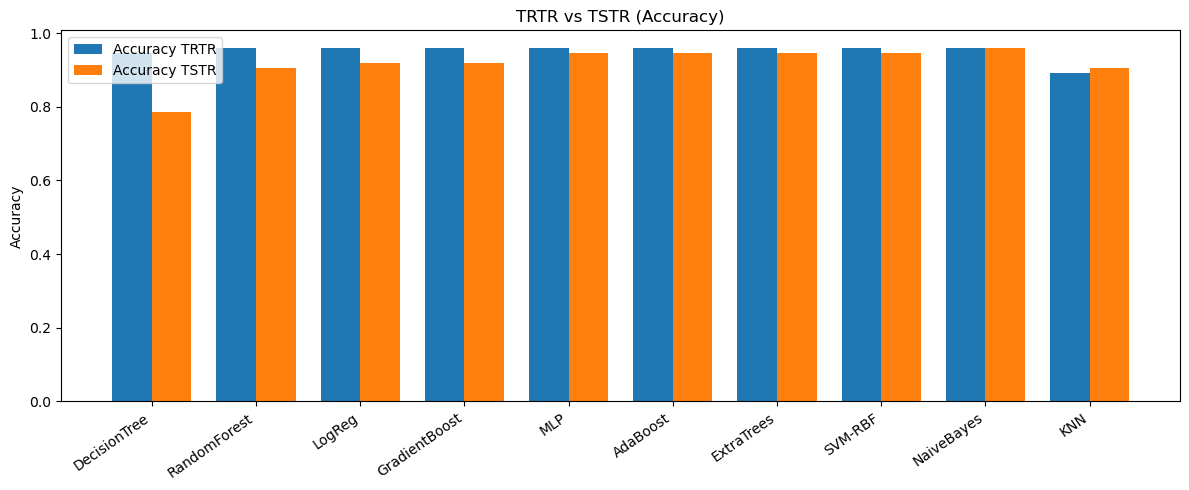

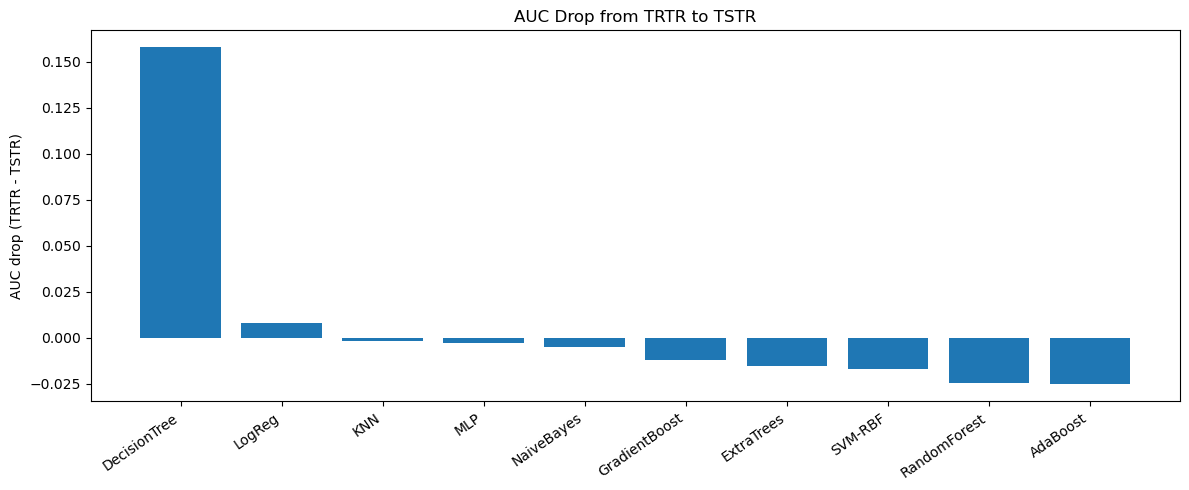

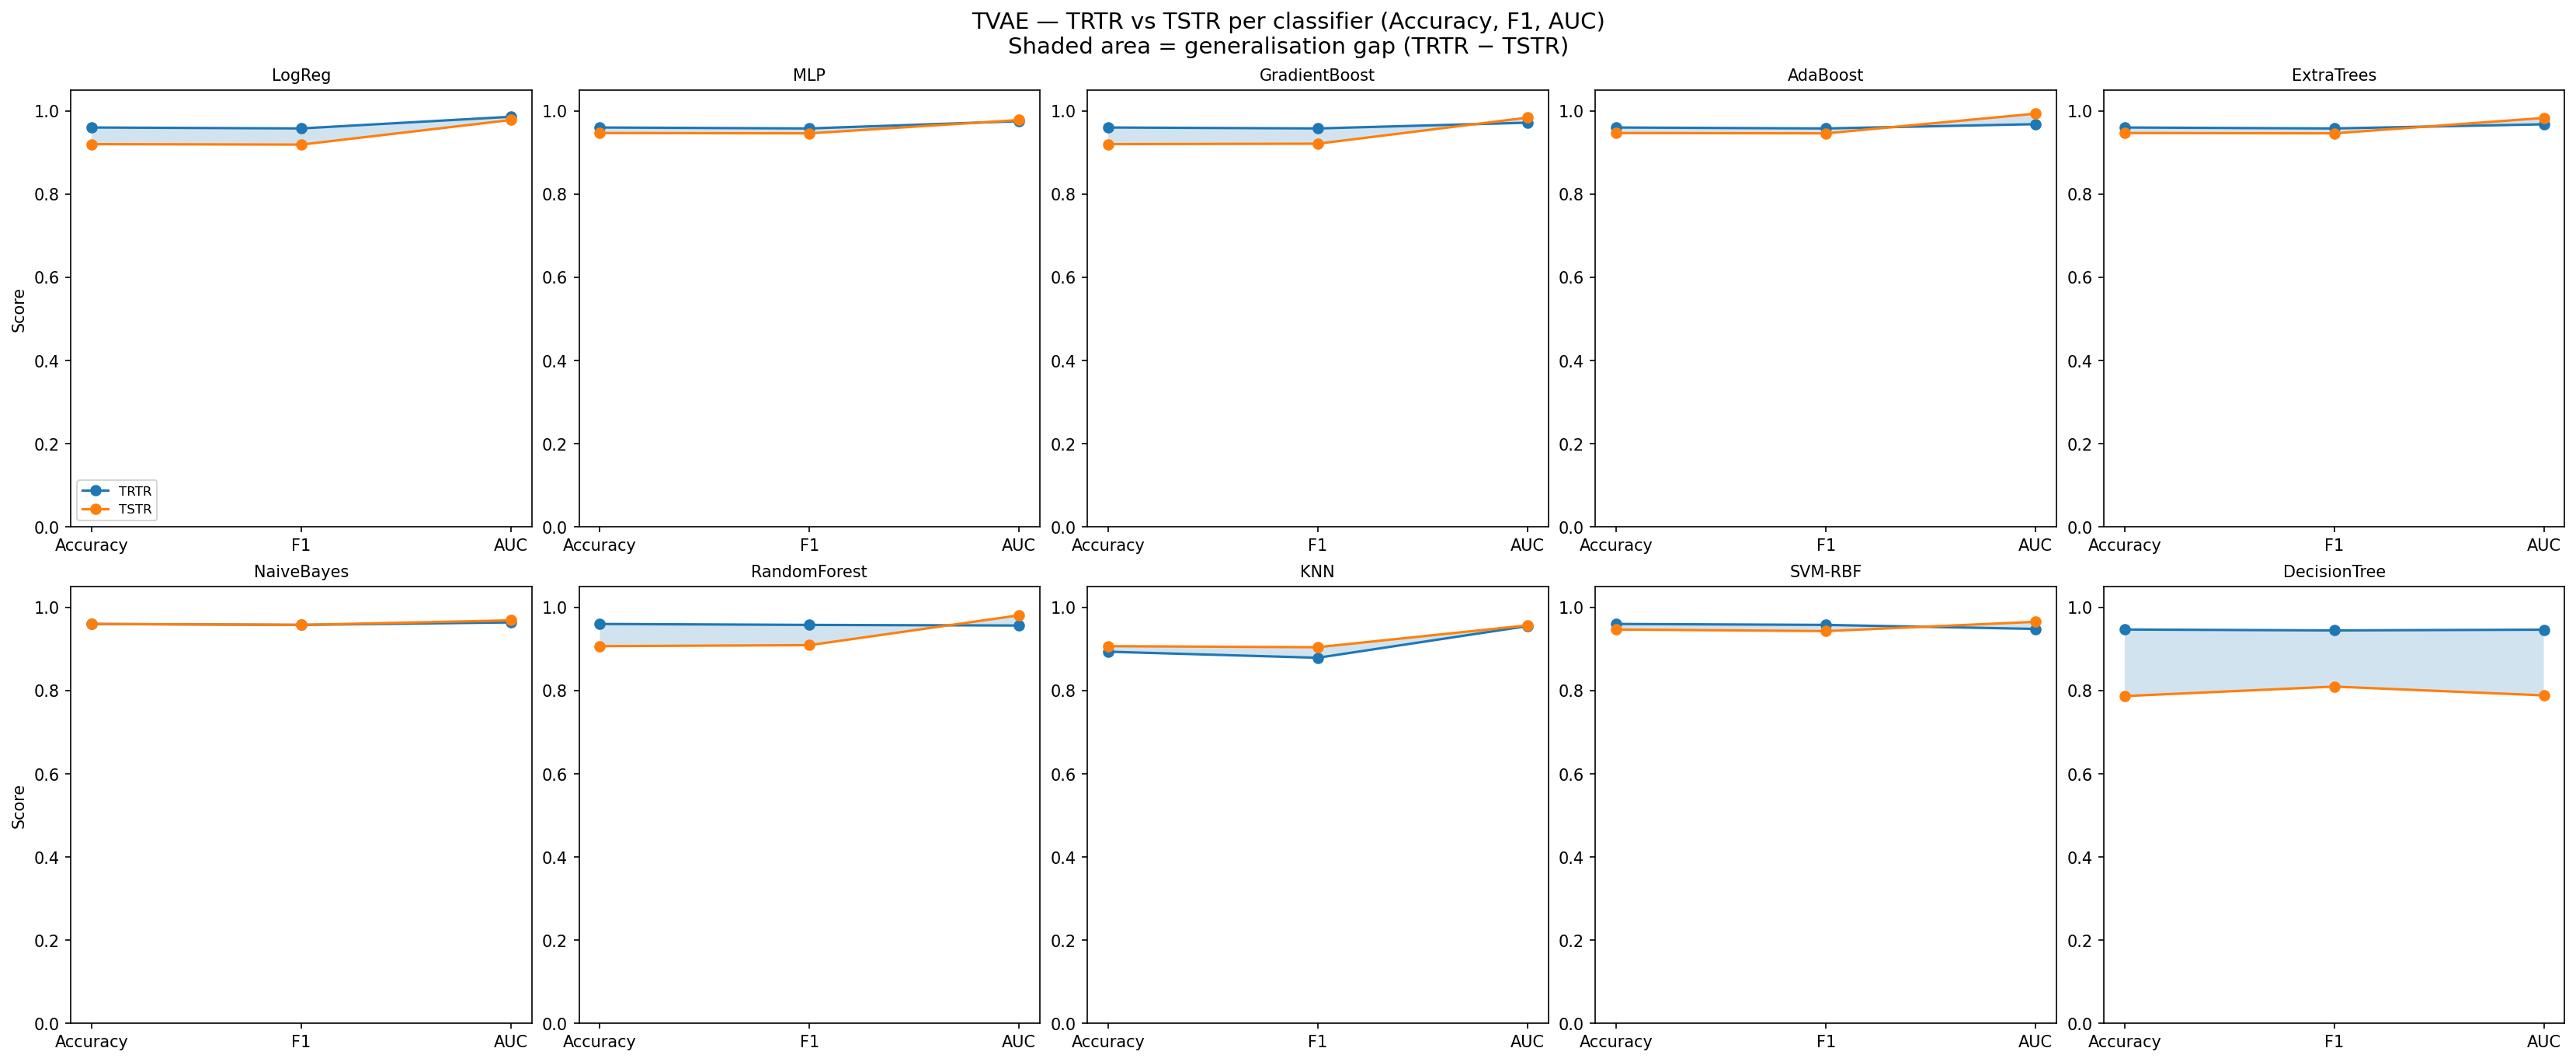

In [67]:
label_col = "Group"

tstr_results_tvae = evaluate_models(
    train_df=synthetic_data_tvae,
    test_df=real_df,
    label_col=label_col,
    models=models
)

print("CopulaGAN - TSTR (Train Synth, Test Real)")
display(tstr_results_tvae)

print('==================================================')

trtr_results = evaluate_models(
    train_df=real_df,
    test_df=real_df,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)


print('==================================================')

comparison = trtr_results.merge(
    tstr_results_tvae, on="Model", suffixes=("_TRTR", "_TSTR")
)

comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
comparison = comparison.sort_values("AUC_Drop", ascending=False)

display(comparison)

plot_trtr_vs_tstr(trtr_results, tstr_results_tvae, metric="AUC")
plot_trtr_vs_tstr(trtr_results, tstr_results_tvae, metric="F1")
plot_trtr_vs_tstr(trtr_results, tstr_results_tvae, metric="Accuracy")

plot_auc_drop(comparison)

plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results_tvae,
    generator_name="TVAE",
    ncols=5
)